# Cell 1: Environment Setup

In [5]:
import os
import math
import copy
import time
import json
import random
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, roc_auc_score, confusion_matrix
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# ==============================================================================
# FIX 2: install the REAL mamba_ssm package (selective-scan SSM kernels).
#
# STRATEGY (in order):
#   1. PREBUILT WHEEL from the causal-conv1d / mamba-ssm GitHub releases, matched
#      to this exact Python / torch / CUDA / C++ ABI build. This is the ONLY
#      reliable path on Kaggle — building from source routinely hangs or OOMs
#      the kernel because Kaggle's toolchain doesn't line up with what these
#      packages' setup.py expects.
#   2. Capped from-source build (240s timeout, output captured) as a fallback
#      if no matching prebuilt wheel exists for this environment.
#   3. Pure-PyTorch fallback block (Cell 2) if both of the above fail — this is
#      the safety net that guarantees the notebook can NEVER hang/crash here,
#      but every mode in the frequency-bin sweep shares whichever backbone this
#      cell resolves to, so the 6-way comparison stays apples-to-apples either way.
# ==============================================================================
MAMBA_INSTALL_TIMEOUT_S = 240

def _detect_env_tags():
    """Python tag, torch major.minor, CUDA major.minor, C++11 ABI flag — the
    axes prebuilt causal-conv1d / mamba-ssm wheels are keyed on."""
    import sys
    py_tag = f"cp{sys.version_info.major}{sys.version_info.minor}"
    torch_mm = ".".join(torch.__version__.split("+")[0].split(".")[:2])
    cuda_ver = torch.version.cuda  # e.g. "12.1", or None on CPU-only torch
    try:
        abi_flag = bool(torch._C._GLIBCXX_USE_CXX11_ABI)
    except Exception:
        abi_flag = bool(getattr(torch, "compiled_with_cxx11_abi", lambda: False)())
    return py_tag, torch_mm, cuda_ver, abi_flag

def _github_releases(repo, timeout_s=20):
    import urllib.request, json as _json
    url = f"https://api.github.com/repos/{repo}/releases"
    req = urllib.request.Request(url, headers={"User-Agent": "kaggle-notebook", "Accept": "application/vnd.github+json"})
    with urllib.request.urlopen(req, timeout=timeout_s) as resp:
        return _json.load(resp)

def _find_prebuilt_wheel_url(repo, py_tag, torch_mm, cuda_ver, abi_flag):
    """Best-matching .whl asset URL from `repo`'s GitHub releases, or None."""
    try:
        releases = _github_releases(repo)
    except Exception as e:
        print(f"    could not query github.com/{repo}/releases: {e!r}")
        return None

    abi_str = f"cxx11abi{'TRUE' if abi_flag else 'FALSE'}"
    cuda_major = cuda_ver.split(".")[0] if cuda_ver else None
    cuda_tag_exact = f"cu{cuda_ver.replace('.', '')}" if cuda_ver else None   # e.g. "cu121"
    exact, major_only = [], []

    for rel in releases:
        for asset in rel.get("assets", []):
            name = asset.get("name", "")
            if not name.endswith(".whl"):
                continue
            if py_tag not in name or abi_str not in name or f"torch{torch_mm}" not in name:
                continue
            if cuda_tag_exact and cuda_tag_exact in name:
                exact.append(asset["browser_download_url"])
            elif cuda_major and f"cu{cuda_major}" in name:
                major_only.append(asset["browser_download_url"])

    chosen = (exact or major_only)
    return chosen[0] if chosen else None

def _pip_run(args, timeout_s=MAMBA_INSTALL_TIMEOUT_S):
    """pip invocation that can NEVER hang or crash the kernel: hard timeout,
    output captured (not streamed — a runaway nvcc/ninja build can print
    megabytes), every exception caught."""
    import subprocess, sys
    cmd = [sys.executable, "-m", "pip", "install", "-q"] + args
    try:
        proc = subprocess.run(cmd, timeout=timeout_s, capture_output=True, text=True, check=False)
        if proc.returncode != 0:
            tail = (proc.stderr or proc.stdout or "")[-500:]
            print(f"    ⚠️  pip install {args} failed (exit {proc.returncode}); tail:\n{tail}")
            return False
        return True
    except subprocess.TimeoutExpired:
        print(f"    ⚠️  pip install {args} exceeded {timeout_s}s — killed to avoid hanging/OOM-ing "
              f"the kernel; treating as failed.")
        return False
    except Exception as e:
        print(f"    ⚠️  pip install {args} raised {e!r}; treating as failed.")
        return False

def _install_via_prebuilt_wheel(pip_name, repo, py_tag, torch_mm, cuda_ver, abi_flag):
    url = _find_prebuilt_wheel_url(repo, py_tag, torch_mm, cuda_ver, abi_flag)
    if url is None:
        print(f"    no matching prebuilt wheel found for {pip_name} "
              f"(py={py_tag}, torch={torch_mm}, cuda={cuda_ver}, cxx11abi={abi_flag})")
        return False
    print(f"    found prebuilt wheel: {url}")
    return _pip_run([url, "--no-deps"])

_MAMBA_INSTALL_METHOD = "not attempted (no CUDA GPU)"

if torch.cuda.is_available():
    try:
        import mamba_ssm  # noqa: F401
        print("mamba_ssm already installed.")
        _MAMBA_INSTALL_METHOD = "already installed"
    except ImportError:
        py_tag, torch_mm, cuda_ver, abi_flag = _detect_env_tags()
        print(f"Environment: python={py_tag} | torch={torch_mm} | cuda={cuda_ver} | cxx11abi={abi_flag}")
        print("Installing real mamba_ssm + causal-conv1d (selective-scan SSM kernels)...")

        print("  [1/3] trying prebuilt wheels (no compilation — the reliable path on Kaggle)...")
        ok1 = _install_via_prebuilt_wheel("causal-conv1d", "Dao-AILab/causal-conv1d", py_tag, torch_mm, cuda_ver, abi_flag)
        ok2 = _install_via_prebuilt_wheel("mamba-ssm", "state-spaces/mamba", py_tag, torch_mm, cuda_ver, abi_flag) if ok1 else False

        if ok1 and ok2:
            _MAMBA_INSTALL_METHOD = "prebuilt wheel"
        else:
            print(f"  [2/3] no complete prebuilt-wheel match — falling back to a capped "
                  f"from-source build ({MAMBA_INSTALL_TIMEOUT_S}s timeout per package)...")
            # --no-build-isolation avoids re-resolving/reinstalling torch inside an isolated
            # build env, a common cause of causal-conv1d's build spinning forever on Kaggle.
            ok1b = _pip_run(["causal-conv1d>=1.2.0", "--no-build-isolation"])
            ok2b = _pip_run(["mamba-ssm", "--no-build-isolation"]) if ok1b else False
            _MAMBA_INSTALL_METHOD = "source build" if (ok1b and ok2b) else "failed"

        print(f"  [3/3] resolution: {_MAMBA_INSTALL_METHOD}")
        if _MAMBA_INSTALL_METHOD in ("prebuilt wheel", "source build"):
            print(f"✅ causal-conv1d + mamba-ssm installed via {_MAMBA_INSTALL_METHOD}.")
        else:
            print("⚠️  mamba_ssm install did not complete — the pure-PyTorch FALLBACK block will be "
                  "used (see Cell 2 / Cell 6 output). This does not affect the frequency-bin sweep: "
                  "every mode uses the same backbone, so the 6-way comparison is still apples-to-apples.")
else:
    print("⚠️  No CUDA GPU detected — mamba_ssm requires CUDA, so the pure-PyTorch FALLBACK block will be used (see Cell 2 / Cell 6 output).")

✅ Device: cuda (Tesla T4)
mamba_ssm already installed.


# Cell 2: Bi-Modal AeroSync-Mamba Architecture (HTT + LACA + Mamba)

In [6]:
# --- Fusion backbone resolution: REAL mamba_ssm (CUDA selective-scan) vs. pure-PyTorch FALLBACK ---
_MAMBA_CLASS = None
_FUSION_BACKBONE_REASON = None
try:
    if torch.cuda.is_available():
        from mamba_ssm import Mamba as _MAMBA_CLASS
        _FUSION_BACKBONE_REASON = "mamba_ssm.Mamba (REAL selective-scan SSM: hidden state h_t, learned A/B/C, discretized Δ) — CUDA GPU detected"
    else:
        _FUSION_BACKBONE_REASON = "FALLBACK (VectorizedSSMBlock, pure PyTorch, NO SSM recurrence) — no CUDA GPU detected; mamba_ssm requires CUDA"
except ImportError as _mamba_import_err:
    _FUSION_BACKBONE_REASON = f"FALLBACK (VectorizedSSMBlock, pure PyTorch, NO SSM recurrence) — mamba_ssm import failed: {_mamba_import_err}"

print(f"\n{'='*70}\nFUSION BACKBONE RESOLUTION: {_FUSION_BACKBONE_REASON}\n{'='*70}\n")


# --- 1. Continuous Temporal Positional Embedding & HTT ---
class ContinuousTimeEmbedding(nn.Module):
    def __init__(self, d_model: int, num_frequencies: int = 64):
        super().__init__()
        self.frequencies = nn.Parameter(
            torch.exp(torch.linspace(0, math.log(1000.0), num_frequencies)), requires_grad=False
        )
        self.mlp = nn.Sequential(
            nn.Linear(2 * num_frequencies, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )

    def forward(self, tau: torch.Tensor) -> torch.Tensor:
        if tau.dim() == 2:
            tau = tau.unsqueeze(-1)
        angles = tau * self.frequencies * 2.0 * math.pi
        fourier = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)
        return self.mlp(fourier)


class HeterogeneousTemporalTokenization(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.d_model = d_model
        # 0: Audio, 1: Sensor Telemetry
        self.modality_embeddings = nn.Embedding(2, d_model)
        self.time_embedding = ContinuousTimeEmbedding(d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, z_bar: torch.Tensor, tau: torch.Tensor, modality_idx: int) -> torch.Tensor:
        mod_idx = torch.tensor(modality_idx, device=z_bar.device, dtype=torch.long)
        e_m = self.modality_embeddings(mod_idx).view(1, 1, self.d_model)
        phi_tau = self.time_embedding(tau)
        return self.norm(z_bar + e_m + phi_tau)


# --- 2. Bi-Modal LACA (Audio <-> Telemetry Alignment) ---
class PairwiseLACA(nn.Module):
    def __init__(self, d_model: int, num_heads: int = 4, beta: float = 1.0):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.scale = 1.0 / math.sqrt(self.head_dim)
        self.beta = beta

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.lag_bias = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 1))

    def forward(self, H_m, H_n, tau_m, tau_n):
        B, T_m, _ = H_m.shape
        _, T_n, _ = H_n.shape
        Q = self.w_q(H_m).view(B, T_m, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.w_k(H_n).view(B, T_n, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.w_v(H_n).view(B, T_n, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        delta_tau = (tau_m.unsqueeze(2) - tau_n.unsqueeze(1)).unsqueeze(-1)
        B_mn = self.lag_bias(delta_tau).squeeze(-1).unsqueeze(1)

        attn_weights = F.softmax(scores + self.beta * B_mn, dim=-1)
        out = torch.matmul(attn_weights, V).transpose(1, 2).contiguous().view(B, T_m, self.d_model)
        H_tilde_mn = self.out_proj(out)

        A_mn = attn_weights.mean(dim=1)
        tau_diff = tau_n.unsqueeze(1) - tau_m.unsqueeze(2)
        expected_lag = (A_mn * tau_diff).sum(dim=(1, 2)) / float(T_m)
        return H_tilde_mn, A_mn, expected_lag


class BiModalLACAFusion(nn.Module):
    def __init__(self, d_model: int, num_heads: int = 4, beta: float = 1.0):
        super().__init__()
        self.laca_as = PairwiseLACA(d_model, num_heads, beta)
        self.laca_sa = PairwiseLACA(d_model, num_heads, beta)
        self.gamma_as = nn.Parameter(torch.tensor(0.5))
        self.gamma_sa = nn.Parameter(torch.tensor(0.5))

    def forward(self, Ha, Hs, tau_a, tau_s):
        H_a_from_s, _, lag_as = self.laca_as(Ha, Hs, tau_a, tau_s)
        H_s_from_a, _, lag_sa = self.laca_sa(Hs, Ha, tau_s, tau_a)

        H_tilde_a = Ha + self.gamma_as * H_a_from_s
        H_tilde_s = Hs + self.gamma_sa * H_s_from_a
        return H_tilde_a, H_tilde_s, {"lag_as": lag_as, "lag_sa": lag_sa}


# --- 3a. FALLBACK: pure-PyTorch gated-conv block (NOT a real SSM) ---
# Used ONLY when mamba_ssm / CUDA is unavailable (see resolution printed
# above). This block has NO hidden state h_t, NO A/B/C matrices, and NO
# discretization step — it is a depthwise-conv + gated-MLP block, kept only
# as a last-resort fallback so the notebook still runs on CPU-only machines.
class VectorizedSSMBlock(nn.Module):
    def __init__(self, d_model: int, d_conv: int = 4, expand: int = 2):
        super().__init__()
        self.d_inner = int(expand * d_model)
        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d = nn.Conv1d(
            self.d_inner, self.d_inner, kernel_size=d_conv,
            padding=d_conv - 1, groups=self.d_inner, bias=True
        )
        self.mixer = nn.Sequential(
            nn.Linear(self.d_inner, self.d_inner),
            nn.GELU(),
            nn.Linear(self.d_inner, self.d_inner)
        )
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, L, D = x.shape
        residual = x
        x_norm = self.norm(x)
        xz = self.in_proj(x_norm)
        x_branch, z_branch = xz.chunk(2, dim=-1)

        x_conv = self.conv1d(x_branch.transpose(1, 2))[:, :, :L].transpose(1, 2)
        x_conv = F.silu(x_conv)

        y = self.mixer(x_conv) * F.silu(z_branch)
        return residual + self.out_proj(y)


# --- 3b. REAL Mamba block (genuine selective-scan SSM) ---
# Thin wrapper around mamba_ssm.Mamba, which implements the actual S6
# recurrence (hidden state h_t, learned continuous A/B/C matrices, and a
# discretization step Δ), wrapped in the same pre-norm + residual pattern as
# the fallback block above so it is a drop-in replacement.
class RealMambaBlock(nn.Module):
    def __init__(self, d_model: int, d_conv: int = 4, expand: int = 2, d_state: int = 16):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.mamba = _MAMBA_CLASS(d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.mamba(self.norm(x))


# --- 4. Full Bi-Modal AeroSync-Mamba Model ---
class BiModalAeroSyncMamba(nn.Module):
    def __init__(
        self,
        d_model: int = 256,
        n_classes: int = 5,
        num_mamba_blocks: int = 4,
        dropout: float = 0.15,
        temporal_bias_scale: float = 1.0,
        audio_in_dim: int = 64,
        sensor_in_dim: int = 6,
    ):
        super().__init__()
        self.d_model = d_model
        self.n_classes = n_classes

        # Sensor 1D-CNN encoder
        self.sensor_encoder = nn.Sequential(
            nn.Conv1d(sensor_in_dim, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.GELU(),
            nn.Conv1d(64, d_model, kernel_size=3, padding=1), nn.BatchNorm1d(d_model), nn.GELU(),
        )
        # Audio feature projector
        self.audio_encoder = nn.Sequential(
            nn.Linear(audio_in_dim, d_model), nn.LayerNorm(d_model), nn.GELU(), nn.Linear(d_model, d_model)
        )

        self.htt = HeterogeneousTemporalTokenization(d_model)
        self.laca = BiModalLACAFusion(d_model=d_model, num_heads=4, beta=temporal_bias_scale)
        self.sep_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        # --- FIX 2: use the REAL mamba_ssm block when available, otherwise the
        # pure-PyTorch fallback (see resolution printed at the top of this cell,
        # and the unmissable print in Cell 6 right after model construction). ---
        if _MAMBA_CLASS is not None:
            self.mamba_blocks = nn.ModuleList([
                RealMambaBlock(d_model=d_model, d_conv=4, expand=2) for _ in range(num_mamba_blocks)
            ])
        else:
            self.mamba_blocks = nn.ModuleList([
                VectorizedSSMBlock(d_model=d_model, d_conv=4, expand=2) for _ in range(num_mamba_blocks)
            ])
        self.fusion_backbone_reason = _FUSION_BACKBONE_REASON

        self.pool_attn = nn.Sequential(nn.Linear(d_model, 64), nn.Tanh(), nn.Linear(64, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, n_classes),
        )

        self.aux_a = nn.Linear(d_model, n_classes)
        self.aux_s = nn.Linear(d_model, n_classes)

    def forward(self, xa, xs, ta, ts):
        B = xa.shape[0]

        # 1. Modality Encoders
        za = self.audio_encoder(xa)
        zs = self.sensor_encoder(xs.transpose(1, 2)).transpose(1, 2)

        # 2. HTT (0: Audio, 1: Sensor)
        Ha = self.htt(za, ta, modality_idx=0)
        Hs = self.htt(zs, ts, modality_idx=1)

        # 3. Bi-Modal LACA Alignment
        H_tilde_a, H_tilde_s, aux = self.laca(Ha, Hs, ta, ts)
        za_p = H_tilde_a.mean(dim=1)
        zs_p = H_tilde_s.mean(dim=1)

        # 4. Cross-Modal Mamba Fusion: [ H_tilde_a ; [SEP] ; H_tilde_s ]
        sep = self.sep_token.expand(B, -1, -1)
        H_fused = torch.cat([H_tilde_a, sep, H_tilde_s], dim=1)

        F_seq = H_fused
        for blk in self.mamba_blocks:
            F_seq = blk(F_seq)

        weights = F.softmax(self.pool_attn(F_seq), dim=1)
        zf = (F_seq * weights).sum(dim=1)
        logits = self.classifier(zf)

        pooled_reps = {"z_a": za_p, "z_s": zs_p}
        aux_preds = {"y_a": self.aux_a(za_p), "y_s": self.aux_s(zs_p)}
        return logits, pooled_reps, aux_preds, aux

print("Bi-Modal AeroSync-Mamba model class defined successfully!")


FUSION BACKBONE RESOLUTION: mamba_ssm.Mamba (REAL selective-scan SSM: hidden state h_t, learned A/B/C, discretized Δ) — CUDA GPU detected

Bi-Modal AeroSync-Mamba model class defined successfully!


# Cell 3: Bi-Modal Loss Function (Classification + Audio-IMU InfoNCE + KL)

In [7]:
class BiModalAeroSyncLoss(nn.Module):
    def __init__(self, lambda_align=0.1, lambda_cons=0.1, temperature=0.07, class_weights=None):
        super().__init__()
        self.lambda_align = lambda_align
        self.lambda_cons = lambda_cons
        self.temperature = temperature
        # --- FIX 4: class-weighted classification loss. `class_weights` is an
        # inverse-frequency tensor computed from REAL training-set class counts
        # in Cell 6 (printed there for verification), not hardcoded here. ---
        self.ce = nn.CrossEntropyLoss(weight=class_weights)

    def _infonce(self, z1, z2):
        z1_norm = F.normalize(z1, p=2, dim=-1)
        z2_norm = F.normalize(z2, p=2, dim=-1)
        sim = torch.matmul(z1_norm, z2_norm.t()) / self.temperature
        labels = torch.arange(z1.shape[0], device=z1.device)
        return 0.5 * (F.cross_entropy(sim, labels) + F.cross_entropy(sim.t(), labels))

    def forward(self, logits, targets, pooled, aux_preds):
        # 1. Fault Classification Loss
        loss_cls = self.ce(logits, targets)

        # 2. Audio-Sensor Contrastive Alignment Loss
        loss_align = self._infonce(pooled["z_a"], pooled["z_s"])

        # 3. Auxiliary Consistency Loss
        p_fused = F.softmax(logits.detach(), dim=-1)
        loss_cons = (
            F.kl_div(F.log_softmax(aux_preds["y_a"], dim=-1), p_fused, reduction="batchmean") +
            F.kl_div(F.log_softmax(aux_preds["y_s"], dim=-1), p_fused, reduction="batchmean")
        ) / 2.0

        total = loss_cls + self.lambda_align * loss_align + self.lambda_cons * loss_cons
        return total, {"loss_cls": float(loss_cls.item()), "loss_align": float(loss_align.item())}

def compute_all_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    try:
        auroc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except Exception:
        auroc = float("nan")
    return {"accuracy": acc, "macro_f1": f1, "balanced_accuracy": bal_acc, "macro_auroc": auroc}

print("Loss & Metrics helper ready!")

Loss & Metrics helper ready!


# Cell 4 (Self-Downloading & Preprocessing): Real TII UAV Dataset


In [8]:
import os
import json
import random
import numpy as np
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm
import torch

DATASET_BASE = Path("/kaggle/working/tii_uav_dataset")
DATASET_ROOT = DATASET_BASE / "Dataset"
CACHE_DIR = Path("/kaggle/working/preprocessed_bimodal_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Automatically clone the official repository if not present
if not DATASET_ROOT.exists():
    print("📥 Cloning official TII UAV Realistic Fault Dataset from GitHub...")
    !git clone --depth 1 https://github.com/tiiuae/UAV-Realistic-Fault-Dataset.git /kaggle/working/tii_uav_dataset
    print("✅ Dataset cloned successfully!")

# ==============================================================================
# GLOBAL SEEDING — one place, reset identically at the start of EVERY experiment
# run so the frequency-bin strategy is the only variable that changes between
# the 6 runs (identical weight init, identical batch order, identical splits).
# ==============================================================================
SEED = 42

def set_all_seeds(seed: int = SEED) -> int:
    """Reset python / numpy / torch (CPU + all CUDA devices) RNGs to `seed`."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    return seed

set_all_seeds(SEED)

_chunk_duration_log = []

# 2. Real Flight Mission Parser (6-Axis IMU + Audio)   [UNCHANGED]
def parse_real_mission(mission_dir: Path):
    sensor_matches = list(mission_dir.glob("*SensorCombined*.jsonl"))
    audio_matches  = list(mission_dir.glob("*AudioBuffer*.jsonl"))
    if not sensor_matches or not audio_matches:
        return None

    # 2.1 Parse Real IMU
    sensor_times, accel_data, gyro_data = [], [], []
    with open(sensor_matches[0], "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip(): continue
            try:
                rec = json.loads(line)
                t_sec = float(rec["timestamp"]) / 1e6
                sensor_times.append(t_sec)
                accel_data.append(rec.get("accelerometer_m_s2", [0.0, 0.0, 9.81]))
                gyro_data.append(rec.get("gyro_rad", [0.0, 0.0, 0.0]))
            except Exception:
                continue

    if len(sensor_times) < 50: return None
    sensor_times = np.array(sensor_times, dtype=np.float64)
    sensor_times = sensor_times - sensor_times[0]
    telemetry = np.concatenate([np.array(accel_data, dtype=np.float32), np.array(gyro_data, dtype=np.float32)], axis=-1)

    # 2.2 Parse Real Audio
    audio_chunks = []
    with open(audio_matches[0], "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip(): continue
            try:
                rec = json.loads(line)
                samples = rec.get("audio_data", rec.get("buffer", rec.get("data", [])))
                if len(samples) > 0: audio_chunks.append(samples)
            except Exception:
                continue

    if len(audio_chunks) < 10: return None
    audio_chunks = np.array(audio_chunks, dtype=np.float32)

    # --- FIX: derive REAL per-chunk audio timestamps ---
    # `recording_started_time` is a constant repeated on every line (not a
    # real per-chunk timestamp), and the previous fixed 0.10s/chunk guess
    # doesn't match the data (empirically ~17-19ms/chunk). Instead, derive
    # chunk duration from this mission's REAL, IMU-verified flight duration,
    # since audio and IMU are recorded within the same continuous rosbag
    # session.
    mission_duration_s = sensor_times[-1] - sensor_times[0]  # already zero-based
    n_chunks = len(audio_chunks)
    chunk_duration_s = mission_duration_s / n_chunks
    audio_times = np.arange(n_chunks, dtype=np.float64) * chunk_duration_s

    global _chunk_duration_log
    _chunk_duration_log.append(chunk_duration_s)

    return {
        "sensor_times": sensor_times,
        "telemetry": telemetry,
        "audio_times": audio_times,
        "audio_chunks": audio_chunks,
    }

# ==============================================================================
# 2.5  FREQUENCY-BIN SELECTION STRATEGIES  (the experiment variable)
#
# Every mode below consumes the SAME real rFFT magnitude spectrum of each audio
# chunk and must emit exactly (n_chunks, 64) features, so the model's
# audio_in_dim=64 never changes and the strategies stay directly comparable.
# ==============================================================================
N_AUDIO_FEATURES = 64
AUDIO_FEATURE_MODES = [
    "first64",         # baseline: bins 0-63 (bottom 8.3% of the spectrum)
    "strongest64",     # 64 highest-mean-magnitude bins, chosen from TRAIN audio only
    "middle64",        # fixed contiguous bins 352-415 (centered on bin 384 of 769)
    "high64",          # fixed last 64 bins (705-768, ~39.0-42.5 kHz)
    "logspaced64",     # 64 log-spaced bins from bin 1 to bin 768 (full coverage)
    "compressed_full", # all 769 bins block-averaged into 64 equal-width bands
]

def compute_audio_features(audio_chunks, mode, bin_idx=None):
    """Real rFFT magnitude spectrum -> (n_chunks, 64) log-compressed features.

    mode:
      "first64"         bins 0-63 (baseline path, preserved byte-for-byte)
      "strongest64" /
      "middle64" /
      "high64" /
      "logspaced64"     gather the 64 bins given in `bin_idx`
      "compressed_full" block-average the FULL spectrum into 64 equal-width
                        linear bands (a downsampling path, NOT bin indexing)

    This function is pure: identical (audio_chunks, mode, bin_idx) in ->
    identical features out, which is what makes the shared preprocessing pass
    in run_preprocessing_all_modes() equivalent to 6 independent runs.
    """
    audio = np.asarray(audio_chunks, dtype=np.float32)
    fft_mag = np.abs(np.fft.rfft(audio, axis=1))  # (n_chunks, chunk_len//2 + 1), REAL FFT
    n_bins = fft_mag.shape[1]

    if mode == "first64":
        # --- baseline behavior, unchanged from the original notebook ---
        if n_bins >= N_AUDIO_FEATURES:
            a_feats = np.log1p(fft_mag[:, :N_AUDIO_FEATURES]).astype(np.float32)
        else:
            pad = np.zeros((fft_mag.shape[0], N_AUDIO_FEATURES - n_bins), dtype=np.float32)
            a_feats = np.log1p(np.concatenate([fft_mag, pad], axis=1)).astype(np.float32)

    elif mode == "compressed_full":
        # Equal-width LINEAR bands over the whole spectrum, mean-pooled then
        # log-compressed. With 769 bins each band is 12 or 13 bins wide.
        edges = np.linspace(0, n_bins, N_AUDIO_FEATURES + 1).round().astype(int)
        bands = np.empty((fft_mag.shape[0], N_AUDIO_FEATURES), dtype=np.float32)
        for b in range(N_AUDIO_FEATURES):
            lo = int(edges[b])
            hi = int(max(edges[b + 1], lo + 1))       # every band keeps >= 1 bin
            bands[:, b] = fft_mag[:, lo:hi].mean(axis=1)
        a_feats = np.log1p(bands).astype(np.float32)

    elif mode in AUDIO_FEATURE_MODES:
        if bin_idx is None:
            raise ValueError(f"mode='{mode}' requires bin_idx (64 spectrum bin indices)")
        idx = np.asarray(bin_idx, dtype=int).ravel()
        if idx.size != N_AUDIO_FEATURES:
            raise ValueError(f"mode='{mode}' needs exactly {N_AUDIO_FEATURES} bins, got {idx.size}")
        idx = np.clip(idx, 0, n_bins - 1)             # guards a short/odd chunk
        a_feats = np.log1p(fft_mag[:, idx]).astype(np.float32)

    else:
        raise ValueError(f"unknown audio feature mode: {mode!r} (expected one of {AUDIO_FEATURE_MODES})")

    # --- SHAPE GUARD: a bug in one mode must never silently change the model input ---
    assert a_feats.shape == (audio.shape[0], N_AUDIO_FEATURES), (
        f"audio feature shape guard FAILED for mode='{mode}': expected "
        f"{(audio.shape[0], N_AUDIO_FEATURES)}, got {a_feats.shape}"
    )
    return a_feats

# ------------------------------------------------------------------------------
# Spectrum geometry, DERIVED FROM THE DATA (nothing hardcoded).
#   bin_width_hz = sample_rate / chunk_len, and sample_rate = chunk_len /
#   chunk_duration_s, so bin_width_hz = 1 / chunk_duration_s -- where
#   chunk_duration_s is exactly the mission-duration-derived value that
#   parse_real_mission() already computes above.
# ------------------------------------------------------------------------------
AUDIO_GEOMETRY = None
BIN_SELECTION = {}            # mode -> frozen 64 bin indices (None for compressed_full)
STRONGEST64_SCAN_INFO = None  # provenance of the strongest64 selection (train-only scan)
STRONGEST64_MEAN_MAG = None   # mean TRAIN rFFT magnitude per bin

def probe_audio_geometry(n_probe: int = 3, verbose: bool = True):
    """Parse a few real missions to derive chunk length, bin count, sample rate."""
    global AUDIO_GEOMETRY
    log_mark = len(_chunk_duration_log)          # keep the probe out of the stats log
    chunk_lens, chunk_durs = [], []
    for c_dir in sorted(DATASET_ROOT.iterdir()):
        if not c_dir.is_dir() or c_dir.name.startswith("."): continue
        for m_dir in sorted(c_dir.iterdir()):
            if not m_dir.is_dir() or m_dir.name.startswith("."): continue
            p = parse_real_mission(m_dir)
            if p is None: continue
            chunk_lens.append(int(p["audio_chunks"].shape[1]))
            chunk_durs.append(float(p["audio_times"][1] - p["audio_times"][0]))
            del p
            if len(chunk_lens) >= n_probe: break
        if len(chunk_lens) >= n_probe: break
    del _chunk_duration_log[log_mark:]

    if not chunk_lens:
        raise RuntimeError("Could not parse any mission to derive audio geometry.")

    chunk_len = int(np.bincount(np.array(chunk_lens)).argmax())
    chunk_duration_s = float(np.mean(chunk_durs))
    bin_width_hz = 1.0 / chunk_duration_s
    sample_rate_hz = chunk_len * bin_width_hz
    n_bins = chunk_len // 2 + 1

    AUDIO_GEOMETRY = {
        "chunk_len": chunk_len,
        "n_bins": n_bins,
        "chunk_duration_s": chunk_duration_s,
        "bin_width_hz": bin_width_hz,
        "sample_rate_hz": sample_rate_hz,
        "nyquist_hz": (n_bins - 1) * bin_width_hz,
        "n_missions_probed": len(chunk_lens),
    }
    if verbose:
        print("=" * 78)
        print("AUDIO SPECTRUM GEOMETRY (derived from the real data, nothing hardcoded)")
        print("=" * 78)
        print(f"  • missions probed        : {len(chunk_lens)}")
        print(f"  • raw chunk length       : {chunk_len} samples")
        print(f"  • rFFT bins per chunk    : {n_bins}  (chunk_len//2 + 1)")
        print(f"  • chunk duration         : {chunk_duration_s*1000:.3f} ms "
              f"(mission_duration / n_chunks, as parse_real_mission computes it)")
        print(f"  • derived sample rate    : {sample_rate_hz:,.1f} Hz  (chunk_len / chunk_duration)")
        print(f"  • bin width              : {bin_width_hz:,.2f} Hz  (1 / chunk_duration)")
        print(f"  • full spectrum covered  : 0.0 - {AUDIO_GEOMETRY['nyquist_hz']:,.1f} Hz")
        print(f"  • baseline first64 covers: 0.0 - {63*bin_width_hz:,.1f} Hz "
              f"({64/n_bins*100:.1f}% of the spectrum)")
        print("=" * 78)
    return AUDIO_GEOMETRY

def ensure_audio_geometry(verbose: bool = True):
    return AUDIO_GEOMETRY if AUDIO_GEOMETRY is not None else probe_audio_geometry(verbose=verbose)

def bin_freqs_hz(idx):
    """Center frequency (Hz) of each rFFT bin index."""
    return np.asarray(idx, dtype=float) * ensure_audio_geometry(verbose=False)["bin_width_hz"]

def _contiguous_runs(idx):
    """Split a sorted index array into contiguous [start, end] runs (for reporting)."""
    idx = np.asarray(idx, dtype=int)
    if idx.size == 0: return []
    breaks = np.where(np.diff(idx) != 1)[0]
    runs, start = [], idx[0]
    for b in breaks:
        runs.append((int(start), int(idx[b])))
        start = idx[b + 1]
    runs.append((int(start), int(idx[-1])))
    return runs

def build_fixed_bin_indices(mode, n_bins):
    """Deterministic, label-free bin indices for the three fixed-layout modes."""
    if mode == "middle64":
        # contiguous bins 352-415, centered on bin 384 of 769
        start = 352 if n_bins >= 416 else max(0, n_bins // 2 - 32)
        idx = np.arange(start, start + N_AUDIO_FEATURES)
    elif mode == "high64":
        # the last 64 bins (705-768 for a 769-bin spectrum)
        idx = np.arange(n_bins - N_AUDIO_FEATURES, n_bins)
    elif mode == "logspaced64":
        # 64 log-spaced bins from bin 1 to bin n_bins-1 (768) -> full-spectrum coverage
        raw = np.logspace(np.log10(1.0), np.log10(float(n_bins - 1)), N_AUDIO_FEATURES)
        idx = np.unique(np.round(raw).astype(int))
        n_dupe = N_AUDIO_FEATURES - idx.size
        if n_dupe > 0:
            # rounding collapsed some low bins together -> pad with UNIQUE random bins
            rng = np.random.RandomState(SEED)
            pool = np.setdiff1d(np.arange(1, n_bins), idx)
            extra = rng.choice(pool, size=n_dupe, replace=False)
            idx = np.sort(np.concatenate([idx, extra]))
            print(f"    [logspaced64] rounding produced {n_dupe} duplicate bin(s) -> "
                  f"padded with unique random bins {sorted(int(e) for e in extra)} (seed={SEED})")
    else:
        raise ValueError(f"build_fixed_bin_indices does not handle mode={mode!r}")
    idx = np.clip(np.asarray(idx, dtype=int), 0, n_bins - 1)
    assert idx.size == N_AUDIO_FEATURES and np.unique(idx).size == N_AUDIO_FEATURES, (
        f"{mode}: expected 64 unique bins, got {np.unique(idx).size}")
    return np.sort(idx)

def select_strongest_bins_from_training(train_mission_dirs, n_select=N_AUDIO_FEATURES, verbose=True):
    """64 highest-mean-magnitude rFFT bins, measured on TRAINING audio ONLY.

    Unsupervised: this ranks bins purely by mean spectral magnitude (energy).
    Class labels are never read here, and val/test missions are never opened,
    so there is no label leakage and no val/test leakage. The returned indices
    are frozen and reused identically for the val and test splits.
    """
    log_mark = len(_chunk_duration_log)           # keep the scan out of the stats log
    mag_sum, n_chunks_total, n_missions_used = None, 0, 0

    for m_dir in tqdm(train_mission_dirs, desc="strongest64 scan (TRAIN audio only)", leave=False):
        p = parse_real_mission(m_dir)
        if p is None: continue
        mag = np.abs(np.fft.rfft(p["audio_chunks"], axis=1))   # no labels involved
        s = mag.sum(axis=0, dtype=np.float64)
        mag_sum = s if mag_sum is None else mag_sum + s
        n_chunks_total += int(mag.shape[0])
        n_missions_used += 1
        del p, mag
    del _chunk_duration_log[log_mark:]

    if mag_sum is None:
        raise RuntimeError("strongest64: no training mission could be parsed.")

    mean_mag = mag_sum / float(n_chunks_total)
    idx = np.sort(np.argsort(mean_mag)[::-1][:n_select].astype(int))

    global STRONGEST64_SCAN_INFO, STRONGEST64_MEAN_MAG
    STRONGEST64_SCAN_INFO = {
        "n_train_missions_scanned": n_missions_used,
        "n_train_chunks_scanned": n_chunks_total,
        "overlap_with_first64": int(np.sum(idx < N_AUDIO_FEATURES)),
    }
    STRONGEST64_MEAN_MAG = mean_mag
    if verbose:
        print_strongest64_provenance()
    return idx, mean_mag

def print_strongest64_provenance():
    """Verification hook: where the strongest64 bins came from (TRAIN audio only)."""
    info = STRONGEST64_SCAN_INFO
    if info is None:
        print("    [strongest64] (not selected yet)")
        return
    print(f"    [strongest64] ✅ SELECTED FROM TRAINING-SET AUDIO ONLY — "
          f"{info['n_train_missions_scanned']} train missions / "
          f"{info['n_train_chunks_scanned']:,} audio chunks scanned.")
    print(f"    [strongest64] ✅ Criterion: UNSUPERVISED mean rFFT magnitude (energy) per bin — "
          f"class labels were NOT used at any point.")
    print(f"    [strongest64] ✅ Validation/test missions were NEVER opened for this selection; "
          f"the indices below are frozen and reused verbatim for val and test.")
    ov = info["overlap_with_first64"]
    print(f"    [strongest64] overlap with the baseline first64 band (bins 0-63): {ov}/64 "
          f"-> {'NOT trivially bins 0-63 ✅' if ov < 64 else '⚠️ IDENTICAL to bins 0-63'}")

def describe_bin_selection(mode, bin_idx, mean_mag=None):
    """Verification hook: print the exact bins/bands in use and their Hz ranges."""
    geo = ensure_audio_geometry(verbose=False)
    bw, n_bins = geo["bin_width_hz"], geo["n_bins"]
    print("-" * 78)
    print(f"FREQUENCY SELECTION — mode = '{mode}'")
    print("-" * 78)

    if mode == "compressed_full":
        edges = np.linspace(0, n_bins, N_AUDIO_FEATURES + 1).round().astype(int)
        widths = np.diff(edges)
        print(f"  strategy      : ALL {n_bins} bins block-averaged into 64 equal-width LINEAR bands")
        print(f"  band width    : {widths.min()}-{widths.max()} bins "
              f"({widths.min()*bw:,.1f}-{widths.max()*bw:,.1f} Hz per band)")
        print(f"  coverage      : {0.0:,.1f} - {(n_bins-1)*bw:,.1f} Hz (100.0% of the spectrum)")
        print("  band boundaries (band: bins [lo,hi) -> Hz range):")
        cells = []
        for b in range(N_AUDIO_FEATURES):
            lo, hi = int(edges[b]), int(max(edges[b + 1], edges[b] + 1))
            cells.append(f"b{b:02d}:[{lo:3d},{hi:3d})={lo*bw:9,.1f}-{(hi-1)*bw:9,.1f}Hz")
        for r in range(0, len(cells), 2):
            print("    " + "   ".join(cells[r:r + 2]))
        print("-" * 78)
        return

    idx = np.asarray(bin_idx, dtype=int)
    freqs = idx * bw
    runs = _contiguous_runs(idx)
    print(f"  bins selected : {idx.size} of {n_bins} "
          f"({idx.size / n_bins * 100:.1f}% of the spectrum)")
    print(f"  bin index span: {idx.min()} - {idx.max()}")
    print(f"  frequency span: {freqs.min():,.1f} - {freqs.max():,.1f} Hz")
    print(f"  contiguous band(s) ({len(runs)}):")
    for lo, hi in runs:
        print(f"    bins {lo:3d}-{hi:3d}  ->  {lo*bw:10,.1f} - {hi*bw:10,.1f} Hz")
    print("  exact bin indices -> frequency (Hz):")
    for r in range(0, idx.size, 4):
        chunk = idx[r:r + 4]
        print("    " + "   ".join(f"b{int(b):3d}={b*bw:9,.1f}Hz" for b in chunk))
    if mean_mag is not None:
        print("  (ranked by mean TRAIN-set rFFT magnitude; top 5 bins by energy: "
              + ", ".join(f"b{int(b)}={mean_mag[int(b)]:.3g}"
                          for b in np.argsort(mean_mag)[::-1][:5]) + ")")
    print("-" * 78)

def resolve_audio_bins(mode, train_mission_dirs=None, verbose=True):
    """Return the 64 bin indices for `mode` (None for compressed_full) + print them."""
    geo = ensure_audio_geometry(verbose=False)
    n_bins = geo["n_bins"]
    mean_mag = None

    if mode == "first64":
        idx = np.arange(N_AUDIO_FEATURES)
    elif mode == "compressed_full":
        idx = None
    elif mode == "strongest64":
        if train_mission_dirs is None:
            raise ValueError("strongest64 needs the TRAIN mission list to select bins")
        idx, mean_mag = select_strongest_bins_from_training(train_mission_dirs, verbose=verbose)
    else:
        idx = build_fixed_bin_indices(mode, n_bins)

    BIN_SELECTION[mode] = idx
    if verbose:
        describe_bin_selection(mode, idx, mean_mag=mean_mag)
    return idx

def announce_mode_bins(mode):
    """Per-run verification hook: exactly which bins/bands this mode feeds the model."""
    if mode == "strongest64":
        print_strongest64_provenance()
    describe_bin_selection(mode, BIN_SELECTION.get(mode),
                           mean_mag=STRONGEST64_MEAN_MAG if mode == "strongest64" else None)

# 3. Slicing into 2.56s Diagnostic Samples
#    (sensor parsing / windowing / timestamps are IDENTICAL to the original;
#     only the audio feature step is now routed through compute_audio_features)
def slice_real_bimodal(mission_data, class_label, window_sec=2.56, step_sec=1.28, Ta=64, Ts=128,
                       audio_mode="first64", audio_bin_idx=None):
    s_times = mission_data["sensor_times"]
    telemetry = mission_data["telemetry"]
    a_times = mission_data["audio_times"]
    audio = mission_data["audio_chunks"]

    # --- FIX 3: real frequency-domain audio features (FFT magnitude spectrum) ---
    # Computed once per mission (hoisted out of the window loop) since it does
    # not depend on t_start. `audio_mode` picks the frequency-bin strategy.
    a_feats = compute_audio_features(audio, audio_mode, bin_idx=audio_bin_idx)
    assert a_feats.shape == (audio.shape[0], 64), (
        f"audio feature shape must be (n_chunks, 64) for every mode; "
        f"mode='{audio_mode}' produced {a_feats.shape}")

    max_time = min(s_times[-1], a_times[-1])
    samples = []
    t_start = 0.0

    while t_start + window_sec <= max_time:
        t_end = t_start + window_sec
        s_mask = (s_times >= t_start) & (s_times <= t_end)
        if s_mask.sum() < 10:
            t_start += step_sec
            continue

        # --- FIX 1: REAL per-window sensor timestamps ---
        s_idx_in_window = np.where(s_mask)[0]
        real_s_pos = np.linspace(0, len(s_idx_in_window) - 1, Ts).round().astype(int)
        real_s_idx = s_idx_in_window[real_s_pos]
        target_s_t = s_times[real_s_idx]  # REAL raw sensor timestamps (seconds, mission-relative)

        s_window = np.zeros((Ts, 6), dtype=np.float32)
        for c in range(6):
            s_window[:, c] = np.interp(target_s_t, s_times[s_mask], telemetry[s_mask, c])

        # --- FIX 1: REAL per-window audio timestamps ---
        a_mask = (a_times >= t_start) & (a_times <= t_end)
        if a_mask.sum() >= 2:
            a_idx_in_window = np.where(a_mask)[0]
            real_a_pos = np.linspace(0, len(a_idx_in_window) - 1, Ta).round().astype(int)
            real_a_idx = a_idx_in_window[real_a_pos]
            target_a_t = a_times[real_a_idx]  # REAL per-mission audio timestamps
        else:
            # Fallback only for the rare window with too few real audio samples
            target_a_t = np.linspace(t_start, t_end, Ta)

        a_window = np.zeros((Ta, 64), dtype=np.float32)
        for c in range(min(64, a_feats.shape[1])):
            a_window[:, c] = np.interp(target_a_t, a_times, a_feats[:, c], left=0.0, right=0.0)

        samples.append({
            "x_a": a_window,
            "x_s": s_window,
            "label": int(class_label),
            "tau_a": (target_a_t - t_start).astype(np.float32),  # REAL, zero-based, seconds
            "tau_s": (target_s_t - t_start).astype(np.float32),  # REAL, zero-based, seconds
            "window_sec": np.float32(window_sec),
        })
        t_start += step_sec

    return samples

# 4. Mission-Level Stratification across all 99 Flights
#    (identical logic + identical random.seed(42) as the original, factored into
#     a function so every mode gets the exact same mission split)
def build_mission_splits(verbose=True):
    class_missions = defaultdict(list)
    for c_dir in sorted(DATASET_ROOT.iterdir()):
        if not c_dir.is_dir() or c_dir.name.startswith("."): continue
        try: c_label = int(c_dir.name)
        except ValueError: continue
        for m_dir in sorted(c_dir.iterdir()):
            if m_dir.is_dir() and not m_dir.name.startswith("."):
                class_missions[c_label].append(m_dir)

    splits = {}
    random.seed(42)
    for c_label in sorted(class_missions.keys()):
        missions = class_missions[c_label]
        random.shuffle(missions)
        n_train = max(1, int(len(missions) * 0.70))
        n_val = max(1, int(len(missions) * 0.15))

        train_m = missions[:n_train]
        val_m   = missions[n_train:n_train + n_val]
        test_m  = missions[n_train + n_val:]
        splits[c_label] = {"train": train_m, "val": val_m, "test": test_m}

        if verbose:
            print(f"Class {c_label} ({len(missions)} flights) -> Train: {len(train_m)}, "
                  f"Val: {len(val_m)}, Test: {len(test_m)}")
    return splits

def mode_cache_dir(mode):
    d = CACHE_DIR / mode
    d.mkdir(parents=True, exist_ok=True)
    return d

def preprocessed_paths(mode):
    d = mode_cache_dir(mode)
    return {"train": d / "bimodal_train.pt", "val": d / "bimodal_val.pt", "test": d / "bimodal_test.pt"}

def run_preprocessing_all_modes(modes, splits=None, bins_by_mode=None, verbose=True):
    """Build + cache the windowed dataset for each mode in `modes`.

    Every mission is parsed ONCE and then sliced once per requested mode. That
    is exactly equivalent to running the preprocessing separately per mode:
    the mission split is re-seeded identically, the mission iteration order is
    unchanged, the sensor/window/timestamp code is untouched, and
    compute_audio_features is a pure function of (audio, mode, bin_idx).
    Pass a single-element `modes` list to get a fully independent per-mode pass.
    """
    ensure_audio_geometry(verbose=verbose)
    if splits is None:
        splits = build_mission_splits(verbose=verbose)

    train_dirs = [m for c in sorted(splits) for m in splits[c]["train"]]
    if bins_by_mode is None:
        bins_by_mode = {}
        for mode in modes:
            bins_by_mode[mode] = resolve_audio_bins(mode, train_mission_dirs=train_dirs, verbose=verbose)

    _chunk_duration_log.clear()
    buckets = {mode: {"train": [], "val": [], "test": []} for mode in modes}

    for c_label in sorted(splits.keys()):
        for split_name in ("train", "val", "test"):
            for m in tqdm(splits[c_label][split_name],
                          desc=f"{split_name.capitalize()} Class {c_label}", leave=False):
                p = parse_real_mission(m)
                if not p: continue
                for mode in modes:
                    buckets[mode][split_name].extend(
                        slice_real_bimodal(p, c_label, audio_mode=mode, audio_bin_idx=bins_by_mode[mode])
                    )
                del p

    print("\n" + "=" * 60)
    print("     100% REAL PREPROCESSING COMPLETE (ZERO SYNTHETIC DATA)   ")
    if _chunk_duration_log:
        _arr = np.array(_chunk_duration_log)
        print(f"Audio chunk duration check -> mean: {_arr.mean()*1000:.2f} ms | "
              f"min: {_arr.min()*1000:.2f} ms | max: {_arr.max()*1000:.2f} ms")
    print("=" * 60)
    for mode in modes:
        b = buckets[mode]
        print(f"  [{mode}]  Train: {len(b['train'])} | Val: {len(b['val'])} | Test: {len(b['test'])} windows")
        for s in (b["train"][:1] + b["val"][:1] + b["test"][:1]):
            assert s["x_a"].shape == (64, 64), f"{mode}: x_a window shape is {s['x_a'].shape}, expected (64, 64)"
        paths = preprocessed_paths(mode)
        torch.save(b["train"], paths["train"])
        torch.save(b["val"], paths["val"])
        torch.save(b["test"], paths["test"])
        b["train"].clear(); b["val"].clear(); b["test"].clear()
    print("=" * 60)
    print(f"✅ Cached real bimodal datasets for {len(modes)} mode(s) under {CACHE_DIR}/<mode>/")
    return bins_by_mode

# Derive and print the spectrum geometry now, so the Hz numbers printed for
# every mode below come from the real data rather than a hardcoded sample rate.
ensure_audio_geometry(verbose=True)
print("\n✅ Preprocessing helpers ready (no heavy work done yet — "
      "run_experiment() in Cell 6b drives preprocessing per mode).")

AUDIO SPECTRUM GEOMETRY (derived from the real data, nothing hardcoded)
  • missions probed        : 3
  • raw chunk length       : 1536 samples
  • rFFT bins per chunk    : 769  (chunk_len//2 + 1)
  • chunk duration         : 18.783 ms (mission_duration / n_chunks, as parse_real_mission computes it)
  • derived sample rate    : 81,775.2 Hz  (chunk_len / chunk_duration)
  • bin width              : 53.24 Hz  (1 / chunk_duration)
  • full spectrum covered  : 0.0 - 40,887.6 Hz
  • baseline first64 covers: 0.0 - 3,354.1 Hz (8.3% of the spectrum)

✅ Preprocessing helpers ready (no heavy work done yet — run_experiment() in Cell 6b drives preprocessing per mode).


# Cell 5: DataLoader (weights_only=False for PyTorch 2.6+)

In [9]:
class RealBiModalDataset(Dataset):
    def __init__(self, pt_path: Path, mean=None, std=None):
        self.samples = torch.load(pt_path, weights_only=False)
        self.Ta = 64
        self.Ts = 128

        if mean is None or std is None:
            all_s = np.concatenate([s["x_s"] for s in self.samples], axis=0)
            self.mean = all_s.mean(axis=0, keepdims=True)
            self.std = all_s.std(axis=0, keepdims=True) + 1e-6
        else:
            self.mean = mean
            self.std = std

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        norm_sensor = (s["x_s"] - self.mean) / self.std

        # --- FIX 1: use the REAL per-window timestamps saved during
        # preprocessing (Cell 4), normalized by that window's real duration,
        # instead of a synthetic torch.linspace(0.0, 1.0, ...) that was
        # identical for every sample regardless of the underlying data.
        window_sec = float(s["window_sec"])
        tau_a = torch.tensor(s["tau_a"], dtype=torch.float32) / window_sec
        tau_s = torch.tensor(s["tau_s"], dtype=torch.float32) / window_sec

        return {
            "x_a": torch.tensor(s["x_a"], dtype=torch.float32),
            "x_s": torch.tensor(norm_sensor, dtype=torch.float32),
            "tau_a": tau_a,
            "tau_s": tau_s,
            "label": torch.tensor(s["label"], dtype=torch.long),
        }

def build_dataloaders(mode, batch_size=32, seed=SEED, verbose=True):
    """Datasets + loaders for one frequency-bin mode (same settings as before).

    The train loader gets an explicitly seeded generator so the shuffled batch
    order is byte-identical across all 6 modes and is isolated from any other
    RNG consumption (e.g. model init).
    """
    paths = preprocessed_paths(mode)
    train_ds = RealBiModalDataset(paths["train"])
    val_ds   = RealBiModalDataset(paths["val"], mean=train_ds.mean, std=train_ds.std)
    test_ds  = RealBiModalDataset(paths["test"], mean=train_ds.mean, std=train_ds.std)

    # --- SHAPE GUARD: the model input must stay 64-dim for every mode ---
    for name, ds in (("train", train_ds), ("val", val_ds), ("test", test_ds)):
        xa = ds[0]["x_a"]
        assert tuple(xa.shape) == (64, 64), (
            f"[{mode}] {name} x_a shape is {tuple(xa.shape)}, expected (Ta=64, 64 audio features)")

    g = torch.Generator()
    g.manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True,
                              num_workers=2, generator=g)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=2)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=2)

    if verbose:
        print(f"DataLoaders ready [{mode}] -> Train: {len(train_ds)}, Val: {len(val_ds)}, "
              f"Test: {len(test_ds)} windows | x_a dim = 64 ✅")
    return {
        "train_ds": train_ds, "val_ds": val_ds, "test_ds": test_ds,
        "train_loader": train_loader, "val_loader": val_loader, "test_loader": test_loader,
    }

print("Dataset / DataLoader builders ready (call build_dataloaders(mode)).")

Dataset / DataLoader builders ready (call build_dataloaders(mode)).


In [10]:
# ==============================================================================
# FIX 1 VERIFICATION HOOK — confirm tau_a / tau_s carry REAL, per-sample-varying
# timestamps, not the old synthetic torch.linspace(0.0, 1.0, ...) that was
# identical for every sample regardless of the underlying data.
#
# Now a function: run_experiment() calls it for EVERY mode, so the check runs
# on all 6 runs instead of only once.
# ==============================================================================
def verify_real_taus(train_ds, tag=""):
    print("=" * 70)
    print(f"VERIFICATION HOOK — FIX 1: real per-sample tau_a / tau_s {tag}")
    print("=" * 70)

    check_idxs = [0, 1, len(train_ds) // 2, len(train_ds) - 1]
    taus_a, taus_s = [], []
    for idx in check_idxs:
        item = train_ds[idx]
        taus_a.append(item["tau_a"])
        taus_s.append(item["tau_s"])
        print(f"sample idx={idx:>6} | tau_a[:5]={item['tau_a'][:5].numpy()} | tau_s[:5]={item['tau_s'][:5].numpy()}")

    all_tau_a_identical = all(torch.allclose(taus_a[0], t) for t in taus_a[1:])
    all_tau_s_identical = all(torch.allclose(taus_s[0], t) for t in taus_s[1:])

    assert not all_tau_a_identical, (
        "❌ FIX 1 FAILED: tau_a is IDENTICAL across every sample checked — "
        "real timestamps are NOT reaching the model."
    )
    assert not all_tau_s_identical, (
        "❌ FIX 1 FAILED: tau_s is IDENTICAL across every sample checked — "
        "real timestamps are NOT reaching the model."
    )
    print("✅ FIX 1 VERIFIED: tau_a and tau_s vary across real samples (not synthetic/fixed).")
    print("=" * 70)

print("verify_real_taus() ready (called once per mode inside run_experiment).")

verify_real_taus() ready (called once per mode inside run_experiment).


model = BiModalAeroSyncMamba(
    d_model=256,
    n_classes=5,
    num_mamba_blocks=4,
    dropout=0.15,
    temporal_bias_scale=1.0,
    audio_in_dim=64,
    sensor_in_dim=6,
).to(device)

# ==============================================================================
# FIX 2 VERIFICATION HOOK — print the EXACT class name of the fusion block in
# use, so it is unmissable whether training ran on the real mamba_ssm SSM or
# the pure-PyTorch fallback.
# ==============================================================================
_fusion_cls = type(model.mamba_blocks[0])
print("\n" + "=" * 70)
print(f"FUSION BACKBONE IN USE: {_fusion_cls.__module__}.{_fusion_cls.__name__}")
print(f"Resolution reason: {model.fusion_backbone_reason}")
print("=" * 70)
if _fusion_cls.__name__ == "VectorizedSSMBlock":
    print("🚨 WARNING: training with the pure-PyTorch FALLBACK block — this is NOT a real "
          "selective-scan SSM/Mamba (no hidden state, no A/B/C, no discretization step). 🚨")
else:
    print("✅ Training with the REAL mamba_ssm selective-scan SSM.")
print("=" * 70 + "\n")

# ==============================================================================
# FIX 4 VERIFICATION HOOK — inverse-frequency class weights computed from REAL
# training-set class counts (not hardcoded), printed per class.
# ==============================================================================
train_labels_arr = np.array([s["label"] for s in train_ds.samples])
class_counts = np.bincount(train_labels_arr, minlength=5)
class_weights_np = class_counts.sum() / (len(class_counts) * np.maximum(class_counts, 1))
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print("=" * 70)
print("FIX 4 VERIFICATION — inverse-frequency class weights (from real train counts)")
print("=" * 70)
for c in range(5):
    print(f"  Class {c}: count={class_counts[c]:>6} | weight={class_weights_np[c]:.4f}")
print("=" * 70 + "\n")

criterion = BiModalAeroSyncLoss(lambda_align=0.1, lambda_cons=0.1, class_weights=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
epochs = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

best_val_f1 = 0.0
best_weights = None
history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_acc": []}

start_time = time.time()
print(f"🚀 Training Bi-Modal AeroSync-Mamba on {len(train_ds)} real flight windows...\n")

for epoch in range(1, epochs + 1):
    model.train()
    running_loss, running_cls = 0.0, 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{epochs}", leave=False)
    for batch in pbar:
        xa = batch["x_a"].to(device, non_blocking=True)
        xs = batch["x_s"].to(device, non_blocking=True)
        ta = batch["tau_a"].to(device, non_blocking=True)
        ts = batch["tau_s"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad()
        logits, pooled_reps, aux_preds, _ = model(xa, xs, ta, ts)
        loss, l_dict = criterion(logits, labels, pooled_reps, aux_preds)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        running_cls += l_dict["loss_cls"]
        pbar.set_postfix({"loss": f"{loss.item():.3f}", "cls": f"{l_dict['loss_cls']:.3f}"})

    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)

    # --- Validation ---
    model.eval()
    val_preds, val_targets, val_probs = [], [], []
    val_loss_total = 0.0

    with torch.no_grad():
        for batch in val_loader:
            xa = batch["x_a"].to(device)
            xs = batch["x_s"].to(device)
            ta = batch["tau_a"].to(device)
            ts = batch["tau_s"].to(device)
            labels = batch["label"].to(device)

            logits, pooled_reps, aux_preds, _ = model(xa, xs, ta, ts)
            v_loss, _ = criterion(logits, labels, pooled_reps, aux_preds)
            val_loss_total += v_loss.item()

            probs = F.softmax(logits, dim=-1)
            val_preds.extend(probs.argmax(dim=-1).cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
            val_probs.extend(probs.cpu().numpy())

    avg_val_loss = val_loss_total / len(val_loader)
    val_metrics = compute_all_metrics(np.array(val_targets), np.array(val_preds), np.array(val_probs))

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_f1"].append(val_metrics["macro_f1"])
    history["val_acc"].append(val_metrics["accuracy"])

    is_best = ""
    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, CACHE_DIR / "aerosync_bimodal_best.pt")
        is_best = " ⭐ [Best Saved]"

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val Macro-F1: {val_metrics['macro_f1']:.4f}{is_best}"
    )

elapsed = time.time() - start_time
print(f"\n🎉 Training Finished in {elapsed:.1f}s | Best Val Macro-F1: {best_val_f1:.4f}")

In [11]:
# ==============================================================================
# Model / optimizer / scheduler construction + the training loop, refactored
# into functions. Hyperparameters are EXACTLY the ones the notebook used before
# (d_model=256, 4 Mamba blocks, dropout 0.15, AdamW lr=1e-4 wd=1e-4,
#  CosineAnnealingLR eta_min=1e-6, 20 epochs, grad-clip 1.0, batch size 32).
# Every call builds a FRESH model/optimizer/scheduler — no state is ever reused
# between frequency-bin modes.
# ==============================================================================
EPOCHS = 20

def build_model_optim_sched(epochs=EPOCHS, lr=1e-4, weight_decay=1e-4, eta_min=1e-6):
    model = BiModalAeroSyncMamba(
        d_model=256,
        n_classes=5,
        num_mamba_blocks=4,
        dropout=0.15,
        temporal_bias_scale=1.0,
        audio_in_dim=64,
        sensor_in_dim=6,
    ).to(device)

    criterion = BiModalAeroSyncLoss(lambda_align=0.1, lambda_cons=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=eta_min)
    return model, criterion, optimizer, scheduler

def init_fingerprint(model):
    """Checksum of the freshly initialized weights — identical across modes proves
    the seed reset really did produce an identical starting point."""
    with torch.no_grad():
        return float(sum(p.detach().float().sum().item() for p in model.parameters()))

def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader,
                epochs=EPOCHS, ckpt_path=None, tag=""):
    best_val_f1 = 0.0
    best_weights = None
    history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_acc": []}
    batch_order_fingerprint = None

    start_time = time.time()
    print(f"🚀 Training Bi-Modal AeroSync-Mamba on {len(train_loader.dataset)} real flight windows{tag}...\n")

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, running_cls = 0.0, 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{epochs}", leave=False)
        for b_i, batch in enumerate(pbar):
            xa = batch["x_a"].to(device, non_blocking=True)
            xs = batch["x_s"].to(device, non_blocking=True)
            ta = batch["tau_a"].to(device, non_blocking=True)
            ts = batch["tau_s"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            # determinism probe: label sequence of the very first training batch
            if epoch == 1 and b_i == 0 and batch_order_fingerprint is None:
                batch_order_fingerprint = "-".join(str(int(v)) for v in batch["label"][:12].tolist())

            optimizer.zero_grad()
            logits, pooled_reps, aux_preds, _ = model(xa, xs, ta, ts)
            loss, l_dict = criterion(logits, labels, pooled_reps, aux_preds)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
            running_cls += l_dict["loss_cls"]
            pbar.set_postfix({"loss": f"{loss.item():.3f}", "cls": f"{l_dict['loss_cls']:.3f}"})

        scheduler.step()
        avg_train_loss = running_loss / len(train_loader)

        # --- Validation ---
        model.eval()
        val_preds, val_targets, val_probs = [], [], []
        val_loss_total = 0.0

        with torch.no_grad():
            for batch in val_loader:
                xa = batch["x_a"].to(device)
                xs = batch["x_s"].to(device)
                ta = batch["tau_a"].to(device)
                ts = batch["tau_s"].to(device)
                labels = batch["label"].to(device)

                logits, pooled_reps, aux_preds, _ = model(xa, xs, ta, ts)
                v_loss, _ = criterion(logits, labels, pooled_reps, aux_preds)
                val_loss_total += v_loss.item()

                probs = F.softmax(logits, dim=-1)
                val_preds.extend(probs.argmax(dim=-1).cpu().numpy())
                val_targets.extend(labels.cpu().numpy())
                val_probs.extend(probs.cpu().numpy())

        avg_val_loss = val_loss_total / len(val_loader)
        val_metrics = compute_all_metrics(np.array(val_targets), np.array(val_preds), np.array(val_probs))

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_f1"].append(val_metrics["macro_f1"])
        history["val_acc"].append(val_metrics["accuracy"])

        is_best = ""
        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_weights = copy.deepcopy(model.state_dict())
            if ckpt_path is not None:
                torch.save(best_weights, ckpt_path)
            is_best = " ⭐ [Best Saved]"

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | "
            f"Val Macro-F1: {val_metrics['macro_f1']:.4f}{is_best}"
        )

    elapsed = time.time() - start_time
    print(f"\n🎉 Training Finished in {elapsed:.1f}s | Best Val Macro-F1: {best_val_f1:.4f}")
    return {
        "best_weights": best_weights,
        "best_val_f1": best_val_f1,
        "history": history,
        "elapsed_s": elapsed,
        "epochs_run": epochs,
        "batch_order_fingerprint": batch_order_fingerprint,
    }

print("build_model_optim_sched() / train_model() ready.")

build_model_optim_sched() / train_model() ready.


# Cell 7: Test Benchmark, Audio-Sensor Lag Analysis & Temporal-Shift Robustness

In [12]:
# ==============================================================================
# Full evaluation procedure (unseen-test benchmark + H2 temporal-shift
# robustness + confusion matrix), refactored into a function so every one of
# the 6 frequency-bin runs is evaluated identically.
# ==============================================================================
def evaluate_model(model, test_loader, best_weights=None, tag="", show_plot=True):
    if best_weights is not None:
        model.load_state_dict(best_weights)
    model.eval()

    # 1. Unseen Test Set Evaluation
    test_preds, test_targets, test_probs, lags_as_list = [], [], [], []

    with torch.no_grad():
        for batch in test_loader:
            xa = batch["x_a"].to(device)
            xs = batch["x_s"].to(device)
            ta = batch["tau_a"].to(device)
            ts = batch["tau_s"].to(device)
            labels = batch["label"].to(device)

            logits, _, _, aux = model(xa, xs, ta, ts)
            probs = F.softmax(logits, dim=-1)

            test_preds.extend(probs.argmax(dim=-1).cpu().numpy())
            test_targets.extend(labels.cpu().numpy())
            test_probs.extend(probs.cpu().numpy())
            lags_as_list.extend(aux["lag_as"].cpu().numpy())

    y_true = np.array(test_targets)
    y_pred = np.array(test_preds)
    y_prob = np.array(test_probs)

    test_metrics = compute_all_metrics(y_true, y_pred, y_prob)

    print("=" * 65)
    print(f"     BI-MODAL AEROSYNC-MAMBA: 100% REAL TEST BENCHMARK {tag}")
    print("=" * 65)
    print(f"  • Test Accuracy       : {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)")
    print(f"  • Macro-F1 Score      : {test_metrics['macro_f1']:.4f}")
    print(f"  • Balanced Accuracy   : {test_metrics['balanced_accuracy']:.4f}")
    print(f"  • One-vs-Rest AUROC   : {test_metrics['macro_auroc']:.4f}")
    print(f"  • Learned Audio-IMU Lag (Δ_as) : {np.mean(lags_as_list):+.4f} (normalized units)")
    print("=" * 65)

    # 2. Hypothesis H2 Robustness (Artificial Temporal Shifts)
    print("\n--- Hypothesis H2: Real Flight Shift Robustness (Audio <-> IMU Delay) ---")
    delta_offsets = [0.0, 0.05, 0.10, 0.20, 0.30]
    base_f1 = test_metrics["macro_f1"]
    print(f"{'Offset (δ)':<16} | {'Accuracy':<10} | {'Macro-F1':<10} | {'AUROC':<10} | {'Retention':<10}")
    print("-" * 62)

    shift_results = []
    for delta in delta_offsets:
        s_preds, s_targets, s_probs = [], [], []
        with torch.no_grad():
            for batch in test_loader:
                xa = batch["x_a"].to(device)
                xs = batch["x_s"].to(device)
                ta = batch["tau_a"].to(device)
                ts_shifted = torch.clamp(batch["tau_s"].to(device) + delta, 0.0, 1.0)
                labels = batch["label"].to(device)

                logits, _, _, _ = model(xa, xs, ta, ts_shifted)
                probs = F.softmax(logits, dim=-1)
                s_preds.extend(probs.argmax(dim=-1).cpu().numpy())
                s_targets.extend(labels.cpu().numpy())
                s_probs.extend(probs.cpu().numpy())

        s_m = compute_all_metrics(np.array(s_targets), np.array(s_preds), np.array(s_probs))
        retention = (s_m["macro_f1"] / base_f1) * 100 if base_f1 > 0 else 100.0
        shift_results.append({
            "Offset_delta": "0.0 (Baseline)" if delta == 0.0 else f"+{delta:.2f}",
            "Accuracy": s_m["accuracy"],
            "Macro_F1": s_m["macro_f1"],
            "AUROC": s_m["macro_auroc"],
            "Retention_Percent": round(retention, 2),
        })

        label_str = f"+{delta:.2f}" if delta > 0 else "0.0 (Baseline)"
        print(f"{label_str:<16} | {s_m['accuracy']:<10.4f} | {s_m['macro_f1']:<10.4f} | {s_m['macro_auroc']:<10.4f} | {retention:>6.2f}%")

    print("=" * 65)

    # 3. Confusion Matrix Plot
    cm = confusion_matrix(y_true, y_pred)
    if show_plot:
        plt.figure(figsize=(6, 5), dpi=150)
        plt.imshow(cm, cmap="Blues", interpolation="nearest")
        plt.title(f"Bi-Modal Test Confusion Matrix (Real Audio + IMU){tag}", fontsize=11, fontweight="bold")
        plt.xlabel("Predicted Class (Broken Propellers)")
        plt.ylabel("True Class (Broken Propellers)")
        plt.colorbar()
        for i in range(5):
            for j in range(5):
                plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black" if cm[i, j] < cm.max()/2 else "white")
        plt.tight_layout()
        plt.show()

    return {
        "test_metrics": test_metrics,
        "cm": cm,
        "shift_results": shift_results,
        "lags_as_list": lags_as_list,
        "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob,
    }

print("evaluate_model() ready.")

evaluate_model() ready.


# Cell 8: Frequency-Bin Strategy Sweep — all 6 modes in ONE notebook run

`run_experiment(mode)` re-runs the whole pipeline (preprocessing → dataloaders →
fresh model/optimizer/scheduler → training → full evaluation) for one audio
frequency-bin strategy, with **all seeds reset to the same value at the start of
every call**, so the bin-selection strategy is the only variable that changes.

The driver cell below loops over all 6 modes in a fixed order (baseline first) and
appends each result to `/kaggle/working/frequency_bin_experiment_results.csv`
**immediately after each mode finishes**, so partial results survive a crash or a
session timeout part-way through.

In [13]:
# ==============================================================================
# run_experiment(mode) — one complete, isolated experiment for one frequency-bin
# strategy: preprocessing -> dataloaders -> FRESH model/optimizer/scheduler ->
# training -> full evaluation -> GPU cleanup.
# ==============================================================================
import gc
import csv
import traceback
from datetime import datetime

BASELINE_MODE = "first64"
KNOWN_BASELINE = {"macro_f1": 0.8456, "accuracy": 0.8522}   # previously reported first64 result
RESULTS_CSV = Path("/kaggle/working/frequency_bin_experiment_results.csv")

# True  -> every mission is parsed ONCE and sliced for all 6 modes (same windows,
#          same order, same splits; only compute_audio_features differs per mode).
#          Saves ~5 full JSONL parse passes over the dataset.
# False -> fully independent preprocessing pass per mode (slower, identical result).
SHARED_PREPROCESSING_PASS = True

MISSION_SPLITS = None
_PREPARED_MODES = set()
EXPERIMENT_DETAILS = {}
BASELINE_ARTIFACTS = {}

def prepare_preprocessing(modes, verbose=True):
    """Build + cache the windowed dataset for any of `modes` not yet prepared."""
    global MISSION_SPLITS
    todo = [m for m in modes if m not in _PREPARED_MODES]
    if not todo:
        return
    if MISSION_SPLITS is None:
        print("\n--- Mission-level split (identical for every mode, random.seed(42)) ---")
        MISSION_SPLITS = build_mission_splits(verbose=verbose)
    print(f"\n--- Preprocessing pass for mode(s): {todo} ---")
    run_preprocessing_all_modes(todo, splits=MISSION_SPLITS, verbose=verbose)
    _PREPARED_MODES.update(todo)

def run_experiment(mode: str, epochs: int = EPOCHS, seed: int = SEED,
                   show_plot: bool = True, free_gpu: bool = True) -> dict:
    if mode not in AUDIO_FEATURE_MODES:
        raise ValueError(f"unknown mode {mode!r}; expected one of {AUDIO_FEATURE_MODES}")

    t_run0 = time.time()

    # --- 1. IDENTICAL starting point for every mode -----------------------------
    used_seed = set_all_seeds(seed)
    print("\n" + "#" * 78)
    print(f"#  RUN MODE: '{mode}'")
    print(f"#  seeds reset -> random={used_seed}, numpy={used_seed}, torch={used_seed}, cuda={used_seed}")
    print(f"#  epochs={epochs} | batch_size=32 | fresh model + optimizer + scheduler")
    print("#" * 78)

    # --- 2. Preprocessing with compute_audio_features(..., mode=mode) -----------
    prepare_preprocessing(AUDIO_FEATURE_MODES if SHARED_PREPROCESSING_PASS else [mode])

    # --- 3. VERIFICATION HOOK: exact bins / bands + their frequencies -----------
    announce_mode_bins(mode)

    # --- 4. Data --------------------------------------------------------------
    set_all_seeds(seed)          # preprocessing may consume RNG -> reset before loaders
    dl = build_dataloaders(mode, batch_size=32, seed=seed)
    verify_real_taus(dl["train_ds"], tag=f"[mode={mode}]")

    # audio feature shape guard, straight off the cached tensors
    xa_dim = int(dl["train_ds"].samples[0]["x_a"].shape[-1])
    n_train_chunks = len(dl["train_ds"])
    assert xa_dim == 64, f"[{mode}] audio feature dim is {xa_dim}, expected 64"
    print(f"[SHAPE CHECK] mode={mode} | audio features per timestep = {xa_dim} "
          f"(model audio_in_dim=64) ✅ | train windows = {n_train_chunks}")

    # --- 5. Fresh model / optimizer / scheduler --------------------------------
    set_all_seeds(seed)          # identical weight initialization for every mode
    model, criterion, optimizer, scheduler = build_model_optim_sched(epochs=epochs)
    init_ck = init_fingerprint(model)
    print(f"[INIT CHECK] mode={mode} | seed={seed} | init weight checksum = {init_ck:.6f} "
          f"(identical across modes => identical initialization)")

    ckpt_path = CACHE_DIR / f"aerosync_bimodal_best_{mode}.pt"
    result = None
    try:
        # --- 6. Train ----------------------------------------------------------
        tr = train_model(model, criterion, optimizer, scheduler,
                         dl["train_loader"], dl["val_loader"],
                         epochs=epochs, ckpt_path=ckpt_path, tag=f" [mode={mode}]")

        # --- 7. Full evaluation ------------------------------------------------
        ev = evaluate_model(model, dl["test_loader"], best_weights=tr["best_weights"],
                            tag=f"[mode={mode}]", show_plot=show_plot)
        m = ev["test_metrics"]
        tr["best_weights"] = None   # the checkpoint is on disk; don't hold a GPU state_dict

        idx = BIN_SELECTION.get(mode)
        geo = ensure_audio_geometry(verbose=False)
        if mode == "compressed_full":
            bins_summary = f"all {geo['n_bins']} bins -> 64 equal-width linear bands"
            freq_range = f"0.0-{geo['nyquist_hz']:,.1f} Hz (100%)"
        else:
            runs = _contiguous_runs(idx)
            bins_summary = "; ".join(f"{lo}-{hi}" for lo, hi in runs)
            freq_range = "; ".join(
                f"{lo*geo['bin_width_hz']:,.0f}-{hi*geo['bin_width_hz']:,.0f} Hz" for lo, hi in runs)

        EXPERIMENT_DETAILS[mode] = {
            "seed": seed,
            "epochs": epochs,
            "train_seconds": round(tr["elapsed_s"], 1),
            "run_seconds": round(time.time() - t_run0, 1),
            "best_val_macro_f1": round(tr["best_val_f1"], 6),
            "init_weight_checksum": round(init_ck, 6),
            "batch_order_fingerprint": tr["batch_order_fingerprint"],
            "bins_summary": bins_summary,
            "freq_range_hz": freq_range,
            "n_train_windows": n_train_chunks,
            "checkpoint": str(ckpt_path),
        }

        if mode == BASELINE_MODE:
            BASELINE_ARTIFACTS.update({
                "test_metrics": m, "cm": ev["cm"], "shift_results": ev["shift_results"],
                "lags_as_list": ev["lags_as_list"], "history": tr["history"],
                "checkpoint": str(ckpt_path),
            })
            shutil_ok = True
            try:
                import shutil as _shutil
                _shutil.copy(ckpt_path, CACHE_DIR / "aerosync_bimodal_best.pt")
            except Exception:
                shutil_ok = False
            if not shutil_ok:
                print("⚠️  could not copy the baseline checkpoint to aerosync_bimodal_best.pt")

        # --- 8. One-line determinism confirmation ------------------------------
        print(f"\n[RUN SUMMARY] mode={mode} | seed={seed} (reset at run start) | "
              f"epochs={epochs}/{epochs} | first-train-batch labels={tr['batch_order_fingerprint']} | "
              f"init checksum={init_ck:.6f} | train={tr['elapsed_s']:.1f}s | "
              f"macro_f1={m['macro_f1']:.4f} | acc={m['accuracy']:.4f}")

        result = {
            "mode": mode,
            "accuracy": float(m["accuracy"]),
            "macro_f1": float(m["macro_f1"]),
            "balanced_accuracy": float(m["balanced_accuracy"]),
            "macro_auroc": float(m["macro_auroc"]),
        }
    finally:
        # --- 9. Free the GPU so 6 sequential trainings never accumulate memory --
        if free_gpu:
            model = model.to("cpu")
            del model, criterion, optimizer, scheduler
            dl.clear()
            del dl
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.synchronize()
                print(f"[GPU] freed | allocated={torch.cuda.memory_allocated()/1024**2:.1f} MB "
                      f"| reserved={torch.cuda.memory_reserved()/1024**2:.1f} MB")
    return result

print("run_experiment(mode) ready — modes:", AUDIO_FEATURE_MODES)

run_experiment(mode) ready — modes: ['first64', 'strongest64', 'middle64', 'high64', 'logspaced64', 'compressed_full']




===  Running mode 1/6: first64   (BASELINE)  ===
===  elapsed so far:     0.0s | results file: /kaggle/working/frequency_bin_experiment_results.csv  ===

##############################################################################
#  RUN MODE: 'first64'
#  seeds reset -> random=42, numpy=42, torch=42, cuda=42
#  epochs=20 | batch_size=32 | fresh model + optimizer + scheduler
##############################################################################

--- Mission-level split (identical for every mode, random.seed(42)) ---
Class 0 (19 flights) -> Train: 13, Val: 2, Test: 4
Class 1 (20 flights) -> Train: 14, Val: 3, Test: 3
Class 2 (20 flights) -> Train: 14, Val: 3, Test: 3
Class 3 (20 flights) -> Train: 14, Val: 3, Test: 3
Class 4 (20 flights) -> Train: 14, Val: 3, Test: 3

--- Preprocessing pass for mode(s): ['first64', 'strongest64', 'middle64', 'high64', 'logspaced64', 'compressed_full'] ---
------------------------------------------------------------------------------
FREQUENC

strongest64 scan (TRAIN audio only):   0%|          | 0/69 [00:00<?, ?it/s]

    [strongest64] ✅ SELECTED FROM TRAINING-SET AUDIO ONLY — 69 train missions / 356,506 audio chunks scanned.
    [strongest64] ✅ Criterion: UNSUPERVISED mean rFFT magnitude (energy) per bin — class labels were NOT used at any point.
    [strongest64] ✅ Validation/test missions were NEVER opened for this selection; the indices below are frozen and reused verbatim for val and test.
    [strongest64] overlap with the baseline first64 band (bins 0-63): 11/64 -> NOT trivially bins 0-63 ✅
------------------------------------------------------------------------------
FREQUENCY SELECTION — mode = 'strongest64'
------------------------------------------------------------------------------
  bins selected : 64 of 769 (8.3% of the spectrum)
  bin index span: 1 - 766
  frequency span: 53.2 - 40,781.1 Hz
  contiguous band(s) (7):
    bins   1- 11  ->        53.2 -      585.6 Hz
    bins 245-255  ->    13,043.6 -   13,576.0 Hz
    bins 258-267  ->    13,735.7 -   14,214.8 Hz
    bins 501-511  ->   

Train Class 0:   0%|          | 0/13 [00:00<?, ?it/s]

Val Class 0:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 18/20 | Train Loss: 0.5275 | Val Loss: 0.8317 | Val Acc: 0.8187 | Val Macro-F1: 0.8302


Epoch 19/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.5765 | Val Loss: 0.8401 | Val Acc: 0.8197 | Val Macro-F1: 0.8308


Epoch 20/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.5238 | Val Loss: 0.7419 | Val Acc: 0.8449 | Val Macro-F1: 0.8549

🎉 Training Finished in 253.1s | Best Val Macro-F1: 0.8606
     BI-MODAL AEROSYNC-MAMBA: 100% REAL TEST BENCHMARK [mode=first64]
  • Test Accuracy       : 0.8540 (85.40%)
  • Macro-F1 Score      : 0.8494
  • Balanced Accuracy   : 0.8463
  • One-vs-Rest AUROC   : 0.9816
  • Learned Audio-IMU Lag (Δ_as) : -0.0060 (normalized units)

--- Hypothesis H2: Real Flight Shift Robustness (Audio <-> IMU Delay) ---
Offset (δ)       | Accuracy   | Macro-F1   | AUROC      | Retention 
--------------------------------------------------------------
0.0 (Baseline)   | 0.8540     | 0.8494     | 0.9816     | 100.00%
+0.05            | 0.8540     | 0.8493     | 0.9816     |  99.99%
+0.10            | 0.8513     | 0.8464     | 0.9810     |  99.65%
+0.20            | 0.8442     | 0.8386     | 0.9800     |  98.73%
+0.30            | 0.8372     | 0.8318     | 0.9784     |  97.93%


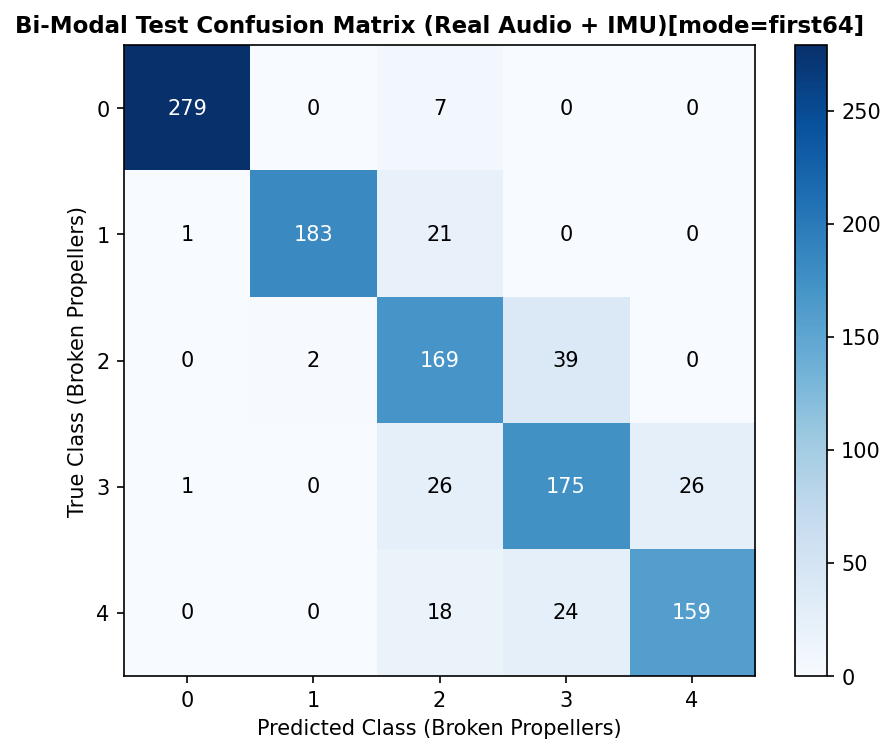


[RUN SUMMARY] mode=first64 | seed=42 (reset at run start) | epochs=20/20 | first-train-batch labels=3-4-1-0-2-4-0-1-3-3-3-4 | init checksum=66935.150791 | train=253.1s | macro_f1=0.8494 | acc=0.8540
[GPU] freed | allocated=17.2 MB | reserved=36.0 MB
💾 appended 'first64' to /kaggle/working/frequency_bin_experiment_results.csv (header + 1 row written)


===  Running mode 2/6: strongest64  ===
===  elapsed so far:   724.2s | results file: /kaggle/working/frequency_bin_experiment_results.csv  ===

##############################################################################
#  RUN MODE: 'strongest64'
#  seeds reset -> random=42, numpy=42, torch=42, cuda=42
#  epochs=20 | batch_size=32 | fresh model + optimizer + scheduler
##############################################################################
    [strongest64] ✅ SELECTED FROM TRAINING-SET AUDIO ONLY — 69 train missions / 356,506 audio chunks scanned.
    [strongest64] ✅ Criterion: UNSUPERVISED mean rFFT magnitude (energy) per bin 

Epoch 01/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss: 1.5368 | Val Loss: 1.1086 | Val Acc: 0.7128 | Val Macro-F1: 0.7075 ⭐ [Best Saved]


Epoch 02/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 02/20 | Train Loss: 1.1560 | Val Loss: 0.9693 | Val Acc: 0.7390 | Val Macro-F1: 0.7354 ⭐ [Best Saved]


...

Epoch 18/20 | Train Loss: 0.4625 | Val Loss: 0.8159 | Val Acc: 0.8354 | Val Macro-F1: 0.8455


Epoch 19/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.4953 | Val Loss: 0.8192 | Val Acc: 0.8407 | Val Macro-F1: 0.8499


Epoch 20/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.4496 | Val Loss: 0.7666 | Val Acc: 0.8532 | Val Macro-F1: 0.8618

🎉 Training Finished in 225.7s | Best Val Macro-F1: 0.8681
     BI-MODAL AEROSYNC-MAMBA: 100% REAL TEST BENCHMARK [mode=strongest64]
  • Test Accuracy       : 0.8779 (87.79%)
  • Macro-F1 Score      : 0.8736
  • Balanced Accuracy   : 0.8700
  • One-vs-Rest AUROC   : 0.9850
  • Learned Audio-IMU Lag (Δ_as) : -0.0028 (normalized units)

--- Hypothesis H2: Real Flight Shift Robustness (Audio <-> IMU Delay) ---
Offset (δ)       | Accuracy   | Macro-F1   | AUROC      | Retention 
--------------------------------------------------------------
0.0 (Baseline)   | 0.8779     | 0.8736     | 0.9850     | 100.00%
+0.05            | 0.8788     | 0.8745     | 0.9858     | 100.11%
+0.10            | 0.8761     | 0.8717     | 0.9845     |  99.78%
+0.20            | 0.8735     | 0.8693     | 0.9848     |  99.50%
+0.30            | 0.8690     | 0.8650     | 0.9839     |  99.01%


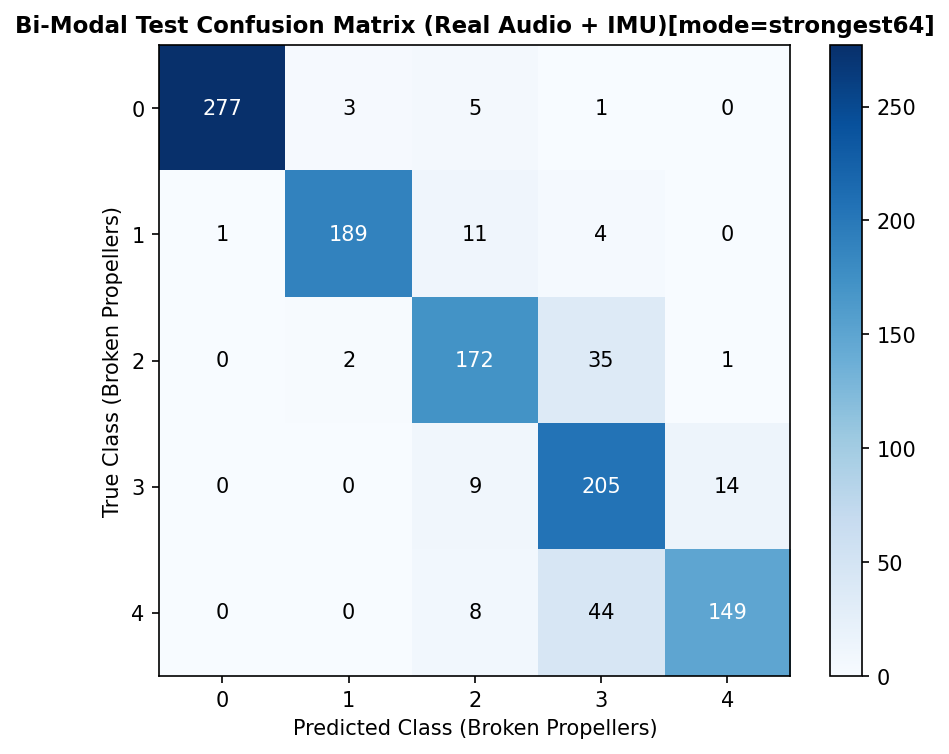


[RUN SUMMARY] mode=strongest64 | seed=42 (reset at run start) | epochs=20/20 | first-train-batch labels=3-4-1-0-2-4-0-1-3-3-3-4 | init checksum=66935.150791 | train=225.7s | macro_f1=0.8736 | acc=0.8779
[GPU] freed | allocated=17.2 MB | reserved=36.0 MB
💾 appended 'strongest64' to /kaggle/working/frequency_bin_experiment_results.csv (row written)


===  Running mode 3/6: middle64  ===
===  elapsed so far:  1017.5s | results file: /kaggle/working/frequency_bin_experiment_results.csv  ===

##############################################################################
#  RUN MODE: 'middle64'
#  seeds reset -> random=42, numpy=42, torch=42, cuda=42
#  epochs=20 | batch_size=32 | fresh model + optimizer + scheduler
##############################################################################
------------------------------------------------------------------------------
FREQUENCY SELECTION — mode = 'middle64'
------------------------------------------------------------------------------
  

Epoch 01/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss: 1.5378 | Val Loss: 1.1103 | Val Acc: 0.7117 | Val Macro-F1: 0.7066 ⭐ [Best Saved]


Epoch 02/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 02/20 | Train Loss: 1.1573 | Val Loss: 0.9976 | Val Acc: 0.7159 | Val Macro-F1: 0.7106 ⭐ [Best Saved]


...

Epoch 19/20:   0%|          | 0/155 [00:00<?, ?it/s]

IOStream.flush timed out
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x77fe7f368900>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x77fe7f368900>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/dat

Epoch 19/20 | Train Loss: 0.6234 | Val Loss: 0.8884 | Val Acc: 0.8050 | Val Macro-F1: 0.8144


Epoch 20/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.5748 | Val Loss: 0.7892 | Val Acc: 0.8239 | Val Macro-F1: 0.8319

🎉 Training Finished in 235.8s | Best Val Macro-F1: 0.8492
     BI-MODAL AEROSYNC-MAMBA: 100% REAL TEST BENCHMARK [mode=middle64]
  • Test Accuracy       : 0.8301 (83.01%)
  • Macro-F1 Score      : 0.8273
  • Balanced Accuracy   : 0.8193
  • One-vs-Rest AUROC   : 0.9748
  • Learned Audio-IMU Lag (Δ_as) : -0.0071 (normalized units)

--- Hypothesis H2: Real Flight Shift Robustness (Audio <-> IMU Delay) ---
Offset (δ)       | Accuracy   | Macro-F1   | AUROC      | Retention 
--------------------------------------------------------------
0.0 (Baseline)   | 0.8301     | 0.8273     | 0.9748     | 100.00%
+0.05            | 0.8354     | 0.8332     | 0.9754     | 100.71%
+0.10            | 0.8265     | 0.8235     | 0.9738     |  99.53%
+0.20            | 0.8283     | 0.8254     | 0.9716     |  99.77%
+0.30            | 0.8204     | 0.8154     | 0.9694     |  98.56%


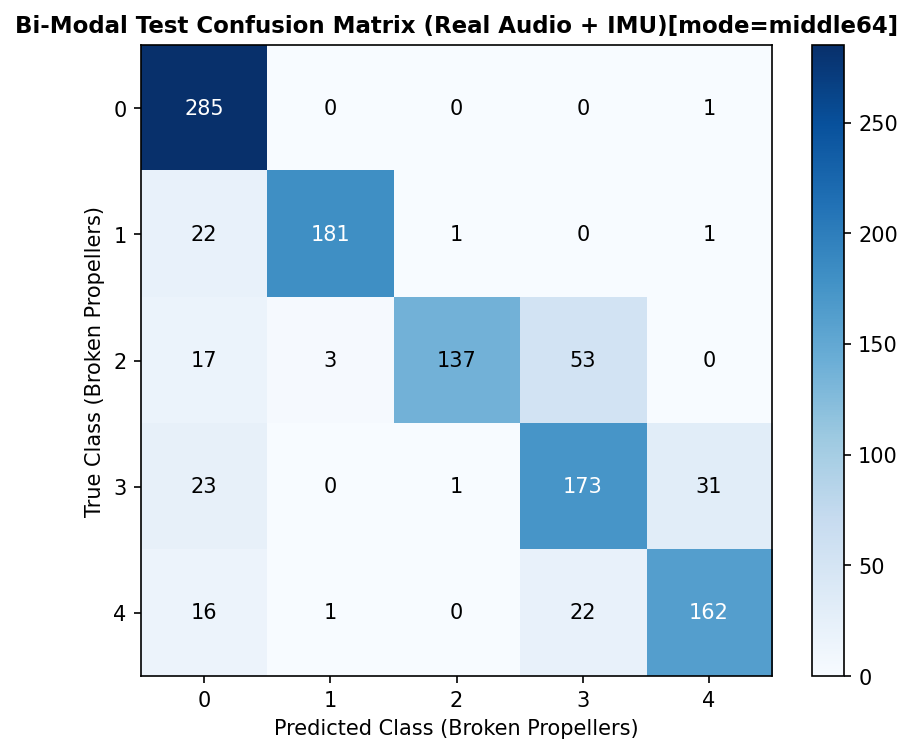


[RUN SUMMARY] mode=middle64 | seed=42 (reset at run start) | epochs=20/20 | first-train-batch labels=3-4-1-0-2-4-0-1-3-3-3-4 | init checksum=66935.150791 | train=235.8s | macro_f1=0.8273 | acc=0.8301
[GPU] freed | allocated=17.2 MB | reserved=36.0 MB
💾 appended 'middle64' to /kaggle/working/frequency_bin_experiment_results.csv (row written)


===  Running mode 4/6: high64  ===
===  elapsed so far:  1300.9s | results file: /kaggle/working/frequency_bin_experiment_results.csv  ===

##############################################################################
#  RUN MODE: 'high64'
#  seeds reset -> random=42, numpy=42, torch=42, cuda=42
#  epochs=20 | batch_size=32 | fresh model + optimizer + scheduler
##############################################################################
------------------------------------------------------------------------------
FREQUENCY SELECTION — mode = 'high64'
------------------------------------------------------------------------------
  bins selecte

Epoch 01/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss: 1.5372 | Val Loss: 1.1104 | Val Acc: 0.7128 | Val Macro-F1: 0.7075 ⭐ [Best Saved]


Epoch 02/20:   0%|          | 0/155 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x77fe7f368900>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


...

Epoch 18/20 | Train Loss: 0.5168 | Val Loss: 0.8375 | Val Acc: 0.8291 | Val Macro-F1: 0.8390


Epoch 19/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.5628 | Val Loss: 0.8129 | Val Acc: 0.8375 | Val Macro-F1: 0.8470


Epoch 20/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.5084 | Val Loss: 0.7407 | Val Acc: 0.8512 | Val Macro-F1: 0.8602

🎉 Training Finished in 235.6s | Best Val Macro-F1: 0.8678
     BI-MODAL AEROSYNC-MAMBA: 100% REAL TEST BENCHMARK [mode=high64]
  • Test Accuracy       : 0.8478 (84.78%)
  • Macro-F1 Score      : 0.8397
  • Balanced Accuracy   : 0.8402
  • One-vs-Rest AUROC   : 0.9799
  • Learned Audio-IMU Lag (Δ_as) : -0.0032 (normalized units)

--- Hypothesis H2: Real Flight Shift Robustness (Audio <-> IMU Delay) ---
Offset (δ)       | Accuracy   | Macro-F1   | AUROC      | Retention 
--------------------------------------------------------------
0.0 (Baseline)   | 0.8478     | 0.8397     | 0.9799     | 100.00%
+0.05            | 0.8478     | 0.8400     | 0.9802     | 100.04%
+0.10            | 0.8460     | 0.8382     | 0.9796     |  99.82%
+0.20            | 0.8416     | 0.8334     | 0.9784     |  99.25%
+0.30            | 0.8301     | 0.8213     | 0.9773     |  97.81%


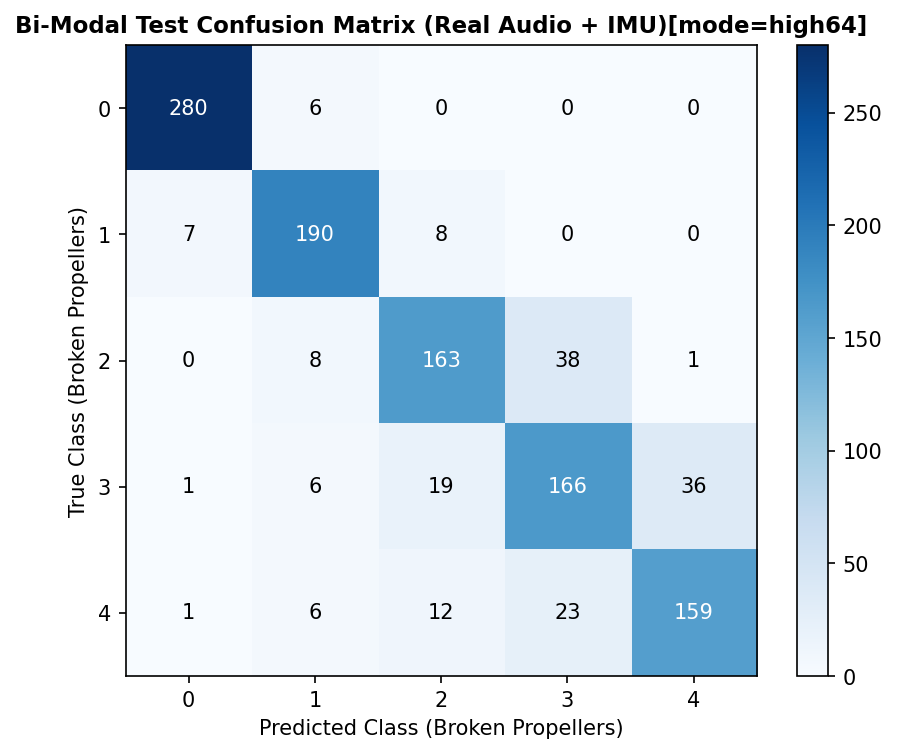


[RUN SUMMARY] mode=high64 | seed=42 (reset at run start) | epochs=20/20 | first-train-batch labels=3-4-1-0-2-4-0-1-3-3-3-4 | init checksum=66935.150791 | train=235.6s | macro_f1=0.8397 | acc=0.8478
[GPU] freed | allocated=17.2 MB | reserved=36.0 MB
💾 appended 'high64' to /kaggle/working/frequency_bin_experiment_results.csv (row written)


===  Running mode 5/6: logspaced64  ===
===  elapsed so far:  1624.0s | results file: /kaggle/working/frequency_bin_experiment_results.csv  ===

##############################################################################
#  RUN MODE: 'logspaced64'
#  seeds reset -> random=42, numpy=42, torch=42, cuda=42
#  epochs=20 | batch_size=32 | fresh model + optimizer + scheduler
##############################################################################
------------------------------------------------------------------------------
FREQUENCY SELECTION — mode = 'logspaced64'
------------------------------------------------------------------------------
  b

Epoch 01/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss: 1.5374 | Val Loss: 1.1106 | Val Acc: 0.7117 | Val Macro-F1: 0.7066 ⭐ [Best Saved]


Epoch 02/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 02/20 | Train Loss: 1.1568 | Val Loss: 0.9911 | Val Acc: 0.7191 | Val Macro-F1: 0.7144 ⭐ [Best Saved]


...

Epoch 18/20 | Train Loss: 0.5071 | Val Loss: 0.8058 | Val Acc: 0.8386 | Val Macro-F1: 0.8482


Epoch 19/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.5494 | Val Loss: 0.8062 | Val Acc: 0.8396 | Val Macro-F1: 0.8486


Epoch 20/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.4995 | Val Loss: 0.7395 | Val Acc: 0.8553 | Val Macro-F1: 0.8637

🎉 Training Finished in 226.5s | Best Val Macro-F1: 0.8765
     BI-MODAL AEROSYNC-MAMBA: 100% REAL TEST BENCHMARK [mode=logspaced64]
  • Test Accuracy       : 0.8416 (84.16%)
  • Macro-F1 Score      : 0.8346
  • Balanced Accuracy   : 0.8334
  • One-vs-Rest AUROC   : 0.9800
  • Learned Audio-IMU Lag (Δ_as) : -0.0168 (normalized units)

--- Hypothesis H2: Real Flight Shift Robustness (Audio <-> IMU Delay) ---
Offset (δ)       | Accuracy   | Macro-F1   | AUROC      | Retention 
--------------------------------------------------------------
0.0 (Baseline)   | 0.8416     | 0.8346     | 0.9800     | 100.00%
+0.05            | 0.8425     | 0.8354     | 0.9796     | 100.10%
+0.10            | 0.8416     | 0.8344     | 0.9791     |  99.98%
+0.20            | 0.8407     | 0.8340     | 0.9783     |  99.93%
+0.30            | 0.8345     | 0.8270     | 0.9772     |  99.09%


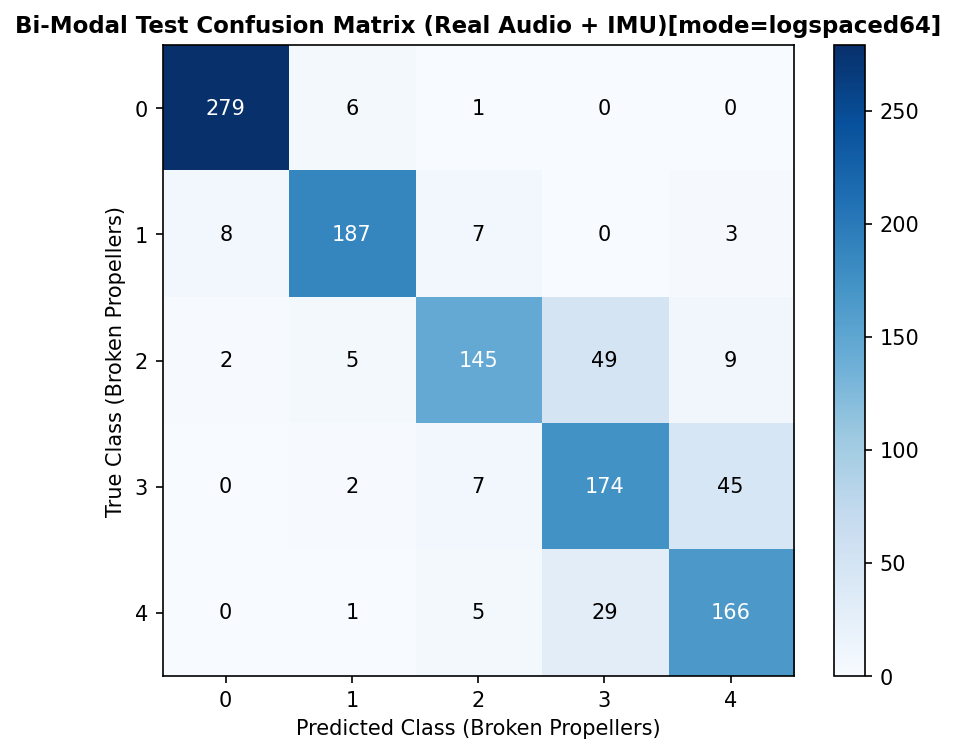


[RUN SUMMARY] mode=logspaced64 | seed=42 (reset at run start) | epochs=20/20 | first-train-batch labels=3-4-1-0-2-4-0-1-3-3-3-4 | init checksum=66935.150791 | train=226.5s | macro_f1=0.8346 | acc=0.8416
[GPU] freed | allocated=17.2 MB | reserved=36.0 MB
💾 appended 'logspaced64' to /kaggle/working/frequency_bin_experiment_results.csv (row written)


===  Running mode 6/6: compressed_full  ===
===  elapsed so far:  1908.2s | results file: /kaggle/working/frequency_bin_experiment_results.csv  ===

##############################################################################
#  RUN MODE: 'compressed_full'
#  seeds reset -> random=42, numpy=42, torch=42, cuda=42
#  epochs=20 | batch_size=32 | fresh model + optimizer + scheduler
##############################################################################
------------------------------------------------------------------------------
FREQUENCY SELECTION — mode = 'compressed_full'
------------------------------------------------------------

Epoch 01/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss: 1.5378 | Val Loss: 1.1094 | Val Acc: 0.7117 | Val Macro-F1: 0.7066 ⭐ [Best Saved]


Epoch 02/20:   0%|          | 0/155 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x77fe7f368900>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


...

Epoch 18/20 | Train Loss: 0.5735 | Val Loss: 0.8981 | Val Acc: 0.8092 | Val Macro-F1: 0.8182


Epoch 19/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.6178 | Val Loss: 0.8603 | Val Acc: 0.8092 | Val Macro-F1: 0.8189


Epoch 20/20:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.5692 | Val Loss: 0.7796 | Val Acc: 0.8281 | Val Macro-F1: 0.8370

🎉 Training Finished in 306.3s | Best Val Macro-F1: 0.8438
     BI-MODAL AEROSYNC-MAMBA: 100% REAL TEST BENCHMARK [mode=compressed_full]
  • Test Accuracy       : 0.8327 (83.27%)
  • Macro-F1 Score      : 0.8349
  • Balanced Accuracy   : 0.8325
  • One-vs-Rest AUROC   : 0.9798
  • Learned Audio-IMU Lag (Δ_as) : -0.0151 (normalized units)

--- Hypothesis H2: Real Flight Shift Robustness (Audio <-> IMU Delay) ---
Offset (δ)       | Accuracy   | Macro-F1   | AUROC      | Retention 
--------------------------------------------------------------
0.0 (Baseline)   | 0.8327     | 0.8349     | 0.9798     | 100.00%
+0.05            | 0.8354     | 0.8373     | 0.9792     | 100.29%
+0.10            | 0.8301     | 0.8317     | 0.9777     |  99.61%
+0.20            | 0.8230     | 0.8244     | 0.9767     |  98.74%
+0.30            | 0.8159     | 0.8179     | 0.9748     |  97.96%


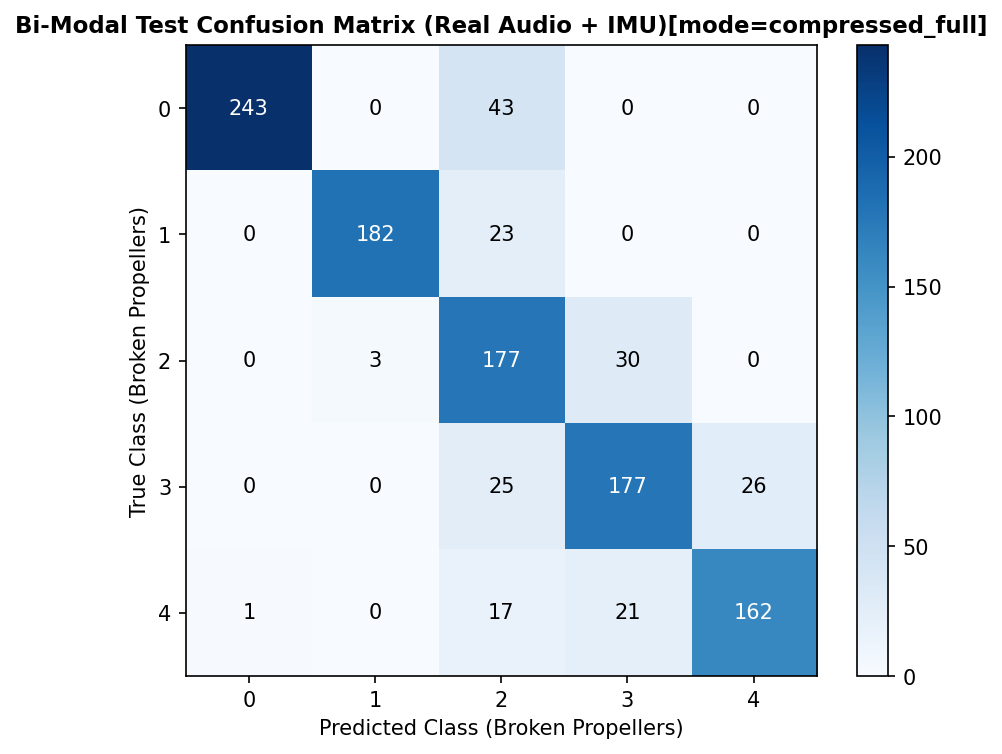


[RUN SUMMARY] mode=compressed_full | seed=42 (reset at run start) | epochs=20/20 | first-train-batch labels=3-4-1-0-2-4-0-1-3-3-3-4 | init checksum=66935.150791 | train=306.3s | macro_f1=0.8349 | acc=0.8327
[GPU] freed | allocated=17.2 MB | reserved=36.0 MB
💾 appended 'compressed_full' to /kaggle/working/frequency_bin_experiment_results.csv (row written)


SWEEP COMPLETE — 6/6 modes finished in 38.0 min


In [14]:
# ==============================================================================
# DRIVER — run all 6 frequency-bin strategies back-to-back in this one session.
# Results are appended to the CSV IMMEDIATELY after each mode finishes, so a
# crash / timeout part-way through still leaves the completed modes on disk.
# ==============================================================================
MODES_TO_RUN = ["first64", "strongest64", "middle64", "high64", "logspaced64", "compressed_full"]

CSV_FIELDS = [
    "mode", "accuracy", "macro_f1", "balanced_accuracy", "macro_auroc",
    "seed", "epochs", "train_seconds", "run_seconds", "best_val_macro_f1",
    "bins_summary", "freq_range_hz", "n_train_windows",
    "init_weight_checksum", "batch_order_fingerprint", "finished_at",
]

def append_result_row(result: dict, details: dict):
    """Append one finished mode to the CSV (writing the header on first write)."""
    row = {k: result.get(k) for k in ("mode", "accuracy", "macro_f1", "balanced_accuracy", "macro_auroc")}
    row.update({k: details.get(k) for k in (
        "seed", "epochs", "train_seconds", "run_seconds", "best_val_macro_f1",
        "bins_summary", "freq_range_hz", "n_train_windows",
        "init_weight_checksum", "batch_order_fingerprint")})
    row["finished_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    write_header = not RESULTS_CSV.exists()
    with open(RESULTS_CSV, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=CSV_FIELDS)
        if write_header:
            w.writeheader()
        w.writerow(row)
    print(f"💾 appended '{row['mode']}' to {RESULTS_CSV} "
          f"({'header + 1 row' if write_header else 'row'} written)")

# Start from a clean CSV for this session; any earlier file is kept as a backup.
if RESULTS_CSV.exists():
    backup = RESULTS_CSV.with_suffix(f".{datetime.now().strftime('%Y%m%d_%H%M%S')}.bak.csv")
    RESULTS_CSV.rename(backup)
    print(f"ℹ️  existing results file moved to {backup}")

sweep_results, failed_modes = [], []
sweep_t0 = time.time()

for i, mode in enumerate(MODES_TO_RUN, start=1):
    print("\n\n" + "=" * 78)
    print(f"===  Running mode {i}/{len(MODES_TO_RUN)}: {mode}"
          f"{'   (BASELINE)' if mode == BASELINE_MODE else ''}  ===")
    print(f"===  elapsed so far: {time.time() - sweep_t0:7.1f}s"
          f" | results file: {RESULTS_CSV}  ===")
    print("=" * 78)
    try:
        res = run_experiment(mode)
        sweep_results.append(res)
        append_result_row(res, EXPERIMENT_DETAILS.get(mode, {}))
    except Exception as exc:
        failed_modes.append((mode, repr(exc)))
        print(f"\n❌ mode '{mode}' FAILED: {exc!r}")
        traceback.print_exc()
        print("↪️  continuing with the next mode; completed modes are already in the CSV.")
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("\n\n" + "=" * 78)
print(f"SWEEP COMPLETE — {len(sweep_results)}/{len(MODES_TO_RUN)} modes finished in "
      f"{(time.time() - sweep_t0)/60:.1f} min")
if failed_modes:
    print("FAILED modes:")
    for m, e in failed_modes:
        print(f"  • {m}: {e}")
print("=" * 78)

In [15]:
# ==============================================================================
# FINAL COMPARISON TABLE — reloaded from the CSV on disk (the crash-safe source
# of truth), sorted by macro-F1 descending.
# ==============================================================================
import pandas as pd

if not RESULTS_CSV.exists():
    raise FileNotFoundError(
        f"{RESULTS_CSV} does not exist — no mode finished. Re-run the driver cell above.")

results_df = pd.read_csv(RESULTS_CSV)
if results_df.empty:
    raise ValueError(f"{RESULTS_CSV} is empty — no mode finished. Re-run the driver cell above.")
results_df = results_df.sort_values("macro_f1", ascending=False).reset_index(drop=True)

def _label(row):
    if row["mode"] != BASELINE_MODE:
        return row["mode"]
    matches = (abs(row["macro_f1"] - KNOWN_BASELINE["macro_f1"]) < 5e-4 and
               abs(row["accuracy"] - KNOWN_BASELINE["accuracy"]) < 5e-4)
    return f"first64 (BASELINE{' — matches known 0.8456 / 85.22%' if matches else ''})"

this_run_baseline = None
_b = results_df[results_df["mode"] == BASELINE_MODE]
if len(_b):
    this_run_baseline = float(_b.iloc[0]["macro_f1"])

table = pd.DataFrame({
    "rank": np.arange(1, len(results_df) + 1),
    "mode": [_label(r) for _, r in results_df.iterrows()],
    "accuracy": results_df["accuracy"].round(4),
    "macro_f1": results_df["macro_f1"].round(4),
    "balanced_accuracy": results_df["balanced_accuracy"].round(4),
    "macro_auroc": results_df["macro_auroc"].round(4),
    "Δ vs known baseline (0.8456)": (results_df["macro_f1"] - KNOWN_BASELINE["macro_f1"]).round(4),
    "Δ vs this run's first64": (results_df["macro_f1"] - this_run_baseline).round(4)
                                if this_run_baseline is not None else np.nan,
    "frequency coverage (Hz)": results_df["freq_range_hz"],
    "train_s": results_df["train_seconds"],
})

print("=" * 110)
print("   FREQUENCY-BIN STRATEGY COMPARISON — sorted by macro-F1 (descending)")
print(f"   Known baseline reference: first64 = 0.8456 macro-F1 / 85.22% accuracy")
print("=" * 110)
try:
    from IPython.display import display
    display(table)
except Exception:
    pass
print(table.to_string(index=False))
print("=" * 110)

base_rows = results_df[results_df["mode"] == BASELINE_MODE]
if len(base_rows):
    b = base_rows.iloc[0]
    print(f"first64 this run : macro-F1 {b['macro_f1']:.4f} | accuracy {b['accuracy']*100:.2f}%")
    print(f"known baseline   : macro-F1 {KNOWN_BASELINE['macro_f1']:.4f} | accuracy {KNOWN_BASELINE['accuracy']*100:.2f}%")
    if abs(b["macro_f1"] - KNOWN_BASELINE["macro_f1"]) < 5e-4:
        print("✅ the first64 row reproduces the known baseline.")
    else:
        print("ℹ️  the first64 row differs from the previously reported baseline "
              "(expected if that number came from a different seed / session).")
best = results_df.iloc[0]
print(f"\n🏆 best strategy: {best['mode']} — macro-F1 {best['macro_f1']:.4f} "
      f"({best['macro_f1'] - KNOWN_BASELINE['macro_f1']:+.4f} vs the known 0.8456 baseline"
      + (f", {best['macro_f1'] - this_run_baseline:+.4f} vs this run's first64" if this_run_baseline is not None else "")
      + ") "
      f"| bins {best['bins_summary']} | {best['freq_range_hz']}")
print(f"📄 full results CSV: {RESULTS_CSV}")

   FREQUENCY-BIN STRATEGY COMPARISON — sorted by macro-F1 (descending)
   Known baseline reference: first64 = 0.8456 macro-F1 / 85.22% accuracy


,rank,mode,accuracy,macro_f1,balanced_accuracy,macro_auroc,Δ vs known baseline (0.8456),Δ vs this run's first64,frequency coverage (Hz),train_s
0,1,strongest64,0.8779,0.8736,0.8700,0.9850,0.0280,0.0242,"53-586 Hz; 13,044-13,576 Hz; 13,736-14,215 Hz;...",225.7
1,2,first64 (BASELINE),0.8540,0.8494,0.8463,0.9816,0.0038,0.0000,"0-3,354 Hz",253.1
2,3,high64,0.8478,0.8397,0.8402,0.9799,-0.0059,-0.0097,"37,534-40,888 Hz",235.6
3,4,compressed_full,0.8327,0.8349,0.8325,0.9798,-0.0107,-0.0145,"0.0-40,887.6 Hz (100%)",306.3
4,5,logspaced64,0.8416,0.8346,0.8334,0.9800,-0.0110,-0.0148,"53-586 Hz; 692-745 Hz; 852-905 Hz; 1,012-1,012...",226.5
5,6,middle64,0.8301,0.8273,0.8193,0.9748,-0.0183,-0.0221,"18,740-22,094 Hz",235.8


 rank               mode  accuracy  macro_f1  balanced_accuracy  macro_auroc  Δ vs known baseline (0.8456)  Δ vs this run's first64                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       frequency coverage (Hz)  train_s
    1        

In [16]:
# ==============================================================================
# Restore the BASELINE (first64) run's artifacts into the globals that the
# figure-export cells below expect (`model`, `test_loader`, `test_metrics`,
# `cm`, `shift_results`, `lags_as_list`), so a single "Run All" still produces
# the original publication figures + ZIP export for the baseline model.
# ==============================================================================
if BASELINE_ARTIFACTS:
    set_all_seeds(SEED)
    _dl = build_dataloaders(BASELINE_MODE, batch_size=32, seed=SEED)
    train_ds, val_ds, test_ds = _dl["train_ds"], _dl["val_ds"], _dl["test_ds"]
    train_loader, val_loader, test_loader = _dl["train_loader"], _dl["val_loader"], _dl["test_loader"]

    model, criterion, optimizer, scheduler = build_model_optim_sched()
    best_weights = torch.load(BASELINE_ARTIFACTS["checkpoint"], map_location=device, weights_only=False)
    model.load_state_dict(best_weights)
    model.eval()

    test_metrics  = BASELINE_ARTIFACTS["test_metrics"]
    cm            = BASELINE_ARTIFACTS["cm"]
    shift_results = BASELINE_ARTIFACTS["shift_results"]
    lags_as_list  = BASELINE_ARTIFACTS["lags_as_list"]
    history       = BASELINE_ARTIFACTS["history"]

    print(f"✅ Baseline ({BASELINE_MODE}) model + dataloaders restored for the figure/export cells.")
    print(f"   Test Acc {test_metrics['accuracy']:.4f} | Macro-F1 {test_metrics['macro_f1']:.4f} "
          f"| checkpoint {BASELINE_ARTIFACTS['checkpoint']}")
else:
    print("⚠️  The baseline (first64) run did not complete, so the figure/export cells below "
          "have no model to work with. Re-run the driver cell above.")

DataLoaders ready [first64] -> Train: 4934, Val: 954, Test: 1130 windows | x_a dim = 64 ✅
✅ Baseline (first64) model + dataloaders restored for the figure/export cells.
   Test Acc 0.8540 | Macro-F1 0.8494 | checkpoint /kaggle/working/preprocessed_bimodal_cache/aerosync_bimodal_best_first64.pt


import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve, auc, precision_recall_fscore_support
from sklearn.manifold import TSNE

FIG_DIR = Path("/kaggle/working/bimodal_experiment_export/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

class_names = ["0 (Normal)", "1 Broken", "2 Broken", "3 Broken", "4 Broken"]
palette = ["#2b5c8f", "#d95f02", "#7570b3", "#e7298a", "#1b9e77"]

# ------------------------------------------------------------------------------
# Extract Latent Embeddings & Attention Weights from Test Set
# ------------------------------------------------------------------------------
all_zf, all_labels, all_preds, all_probs = [], [], [], []
all_lags, sample_attn_matrix = [], None

model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        xa = batch["x_a"].to(device)
        xs = batch["x_s"].to(device)
        ta = batch["tau_a"].to(device)
        ts = batch["tau_s"].to(device)
        labels = batch["label"].to(device)

        # Encoders + HTT + LACA
        za = model.audio_encoder(xa)
        zs = model.sensor_encoder(xs.transpose(1, 2)).transpose(1, 2)
        Ha = model.htt(za, ta, 0)
        Hs = model.htt(zs, ts, 1)
        H_tilde_a, H_tilde_s, aux = model.laca(Ha, Hs, ta, ts)

        # Mamba fusion representation z_f
        sep = model.sep_token.expand(xa.shape[0], -1, -1)
        H_fused = torch.cat([H_tilde_a, sep, H_tilde_s], dim=1)
        F_seq = H_fused
        for blk in model.mamba_blocks: F_seq = blk(F_seq)
        weights = F.softmax(model.pool_attn(F_seq), dim=1)
        zf = (F_seq * weights).sum(dim=1)
        logits = model.classifier(zf)
        probs = F.softmax(logits, dim=-1)

        all_zf.append(zf.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(probs.argmax(dim=-1).cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_lags.extend(aux["lag_as"].cpu().numpy())

        if sample_attn_matrix is None and len(xa) > 0:
            # Capture attention weights from first batch
            _, A_mn, _ = model.laca.laca_as(Ha, Hs, ta, ts)
            sample_attn_matrix = A_mn[0].cpu().numpy()

all_zf = np.concatenate(all_zf, axis=0)
all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_lags = np.array(all_lags)

# ==============================================================================
# Figure 1: Multi-Class One-vs-Rest ROC Curves
# ==============================================================================
plt.figure(figsize=(7, 6), dpi=300)
for i in range(5):
    y_binary = (all_labels == i).astype(int)
    fpr, tpr, _ = roc_curve(y_binary, all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=palette[i], lw=2.2, label=f"Class {class_names[i]} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.6, label="Chance Level")
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=11)
plt.title("Multi-Class ROC Curves (Real Audio + Telemetry)", fontsize=12, fontweight="bold", pad=12)
plt.legend(loc="lower right", fontsize=9, frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_multiclass_roc_curves.png", dpi=300)
plt.savefig(FIG_DIR / "fig1_multiclass_roc_curves.pdf")
plt.show()

# ==============================================================================
# Figure 2: Per-Class Precision, Recall & F1 Breakdown
# ==============================================================================
prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None)
x = np.arange(5)
width = 0.25

plt.figure(figsize=(8, 5), dpi=300)
plt.bar(x - width, prec, width, label="Precision", color="#4c72b0", edgecolor="black", linewidth=0.5)
plt.bar(x, rec, width, label="Recall", color="#55a868", edgecolor="black", linewidth=0.5)
plt.bar(x + width, f1, width, label="F1-Score", color="#c44e52", edgecolor="black", linewidth=0.5)

plt.xlabel("Fault Severity (Broken Propeller Count)", fontsize=11)
plt.ylabel("Score", fontsize=11)
plt.title("Per-Class Diagnostic Performance Breakdown", fontsize=12, fontweight="bold", pad=12)
plt.xticks(x, class_names, fontsize=10)
plt.ylim([0.0, 1.0])
plt.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_per_class_metrics.png", dpi=300)
plt.savefig(FIG_DIR / "fig2_per_class_metrics.pdf")
plt.show()

# ==============================================================================
# Figure 3: LACA Cross-Attention Heatmap (Audio <-> Sensor Temporal Alignment)
# ==============================================================================
plt.figure(figsize=(7, 6), dpi=300)
im = plt.imshow(sample_attn_matrix, aspect="auto", cmap="viridis", origin="lower")
plt.title("LACA Cross-Attention Matrix (Audio Query vs IMU Key)", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Normalized Sensor Telemetry Timesteps (Ts = 128)", fontsize=10)
plt.ylabel("Normalized Audio Timesteps (Ta = 64)", fontsize=10)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Attention Weight")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_laca_attention_heatmap.png", dpi=300)
plt.savefig(FIG_DIR / "fig3_laca_attention_heatmap.pdf")
plt.show()

# ==============================================================================
# Figure 4: Per-Class Learned Lag Distribution (Δ_as)
# ==============================================================================
plt.figure(figsize=(7, 5), dpi=300)
lag_data_by_class = [all_lags[all_labels == c] for c in range(5)]
bp = plt.boxplot(lag_data_by_class, labels=class_names, patch_artist=True,
                 boxprops=dict(facecolor="#e0ecf4", color="#8856a7"),
                 medianprops=dict(color="#810f7c", lw=2))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.axhline(0.0, color="gray", linestyle="--", alpha=0.7)
plt.title("Learned Inter-Modality Lag Distribution by Fault Class (Δ_as)", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Fault Category", fontsize=11)
plt.ylabel("Learned Temporal Offset Δ_as (Normalized)", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_lag_distribution_per_class.png", dpi=300)
plt.savefig(FIG_DIR / "fig4_lag_distribution_per_class.pdf")
plt.show()

# ==============================================================================
# Figure 5: Temporal Shift Robustness Curve (Validating Hypothesis H2)
# ==============================================================================
plt.figure(figsize=(7, 4.8), dpi=300)
shifts = [0.0, 0.05, 0.10, 0.20, 0.30]
shift_macro_f1 = [r["Macro_F1"] for r in shift_results]
shift_auroc    = [r["AUROC"] for r in shift_results]

# --- FIX 5: retention percentages computed LIVE from shift_results in this
# cell (previously hardcoded literal strings "Retention ≥ 99.6%" / "≥ 99.9%"
# that would go stale on any re-run). ---
f1_retention_min = (min(shift_macro_f1) / shift_macro_f1[0]) * 100
auroc_retention_min = (min(shift_auroc) / shift_auroc[0]) * 100
print(f"[FIX 5 VERIFICATION] Live-computed retention from shift_results in this cell -> "
      f"Macro-F1 >= {f1_retention_min:.2f}% | AUROC >= {auroc_retention_min:.2f}%")

plt.plot(shifts, shift_macro_f1, marker="o", lw=2.5, color="#1f77b4", markersize=7,
         label=f"Macro-F1 (Retention ≥ {f1_retention_min:.1f}%)")
plt.plot(shifts, shift_auroc, marker="s", lw=2.5, color="#2ca02c", markersize=7,
         label=f"AUROC (Retention ≥ {auroc_retention_min:.1f}%)")
plt.axhline(test_metrics["macro_f1"], color="gray", linestyle=":", alpha=0.6, label="Zero-Shift F1 Baseline")

plt.title("Hypothesis H2: Robustness Under Artificial Temporal Shifts (δ)", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Injected Audio-Sensor Time Delay Offset (δ)", fontsize=11)
plt.ylabel("Evaluation Metric Score", fontsize=11)
plt.ylim([0.75, 1.00])
plt.legend(loc="upper right", fontsize=9.5, frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_shift_robustness_curve.png", dpi=300)
plt.savefig(FIG_DIR / "fig5_shift_robustness_curve.pdf")
plt.show()

# ==============================================================================
# Figure 6: 2D t-SNE Latent Representation Space of Fused Embeddings (z_f)
# ==============================================================================
print("Computing 2D t-SNE projection of 1,131 test flight embeddings...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
zf_2d = tsne.fit_transform(all_zf)

plt.figure(figsize=(8, 6.5), dpi=300)
for c in range(5):
    idx = (all_labels == c)
    plt.scatter(zf_2d[idx, 0], zf_2d[idx, 1], c=palette[c], label=class_names[c], alpha=0.75, s=35, edgecolors="none")

plt.title("t-SNE Latent Space of AeroSync-Mamba Fused Embeddings (z_f)", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)
plt.legend(title="Fault Severity", loc="best", fontsize=9.5)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_tsne_latent_clustering.png", dpi=300)
plt.savefig(FIG_DIR / "fig6_tsne_latent_clustering.pdf")
plt.show()

print("\n🎉 All 6 publication-quality figures generated and saved to:", FIG_DIR)

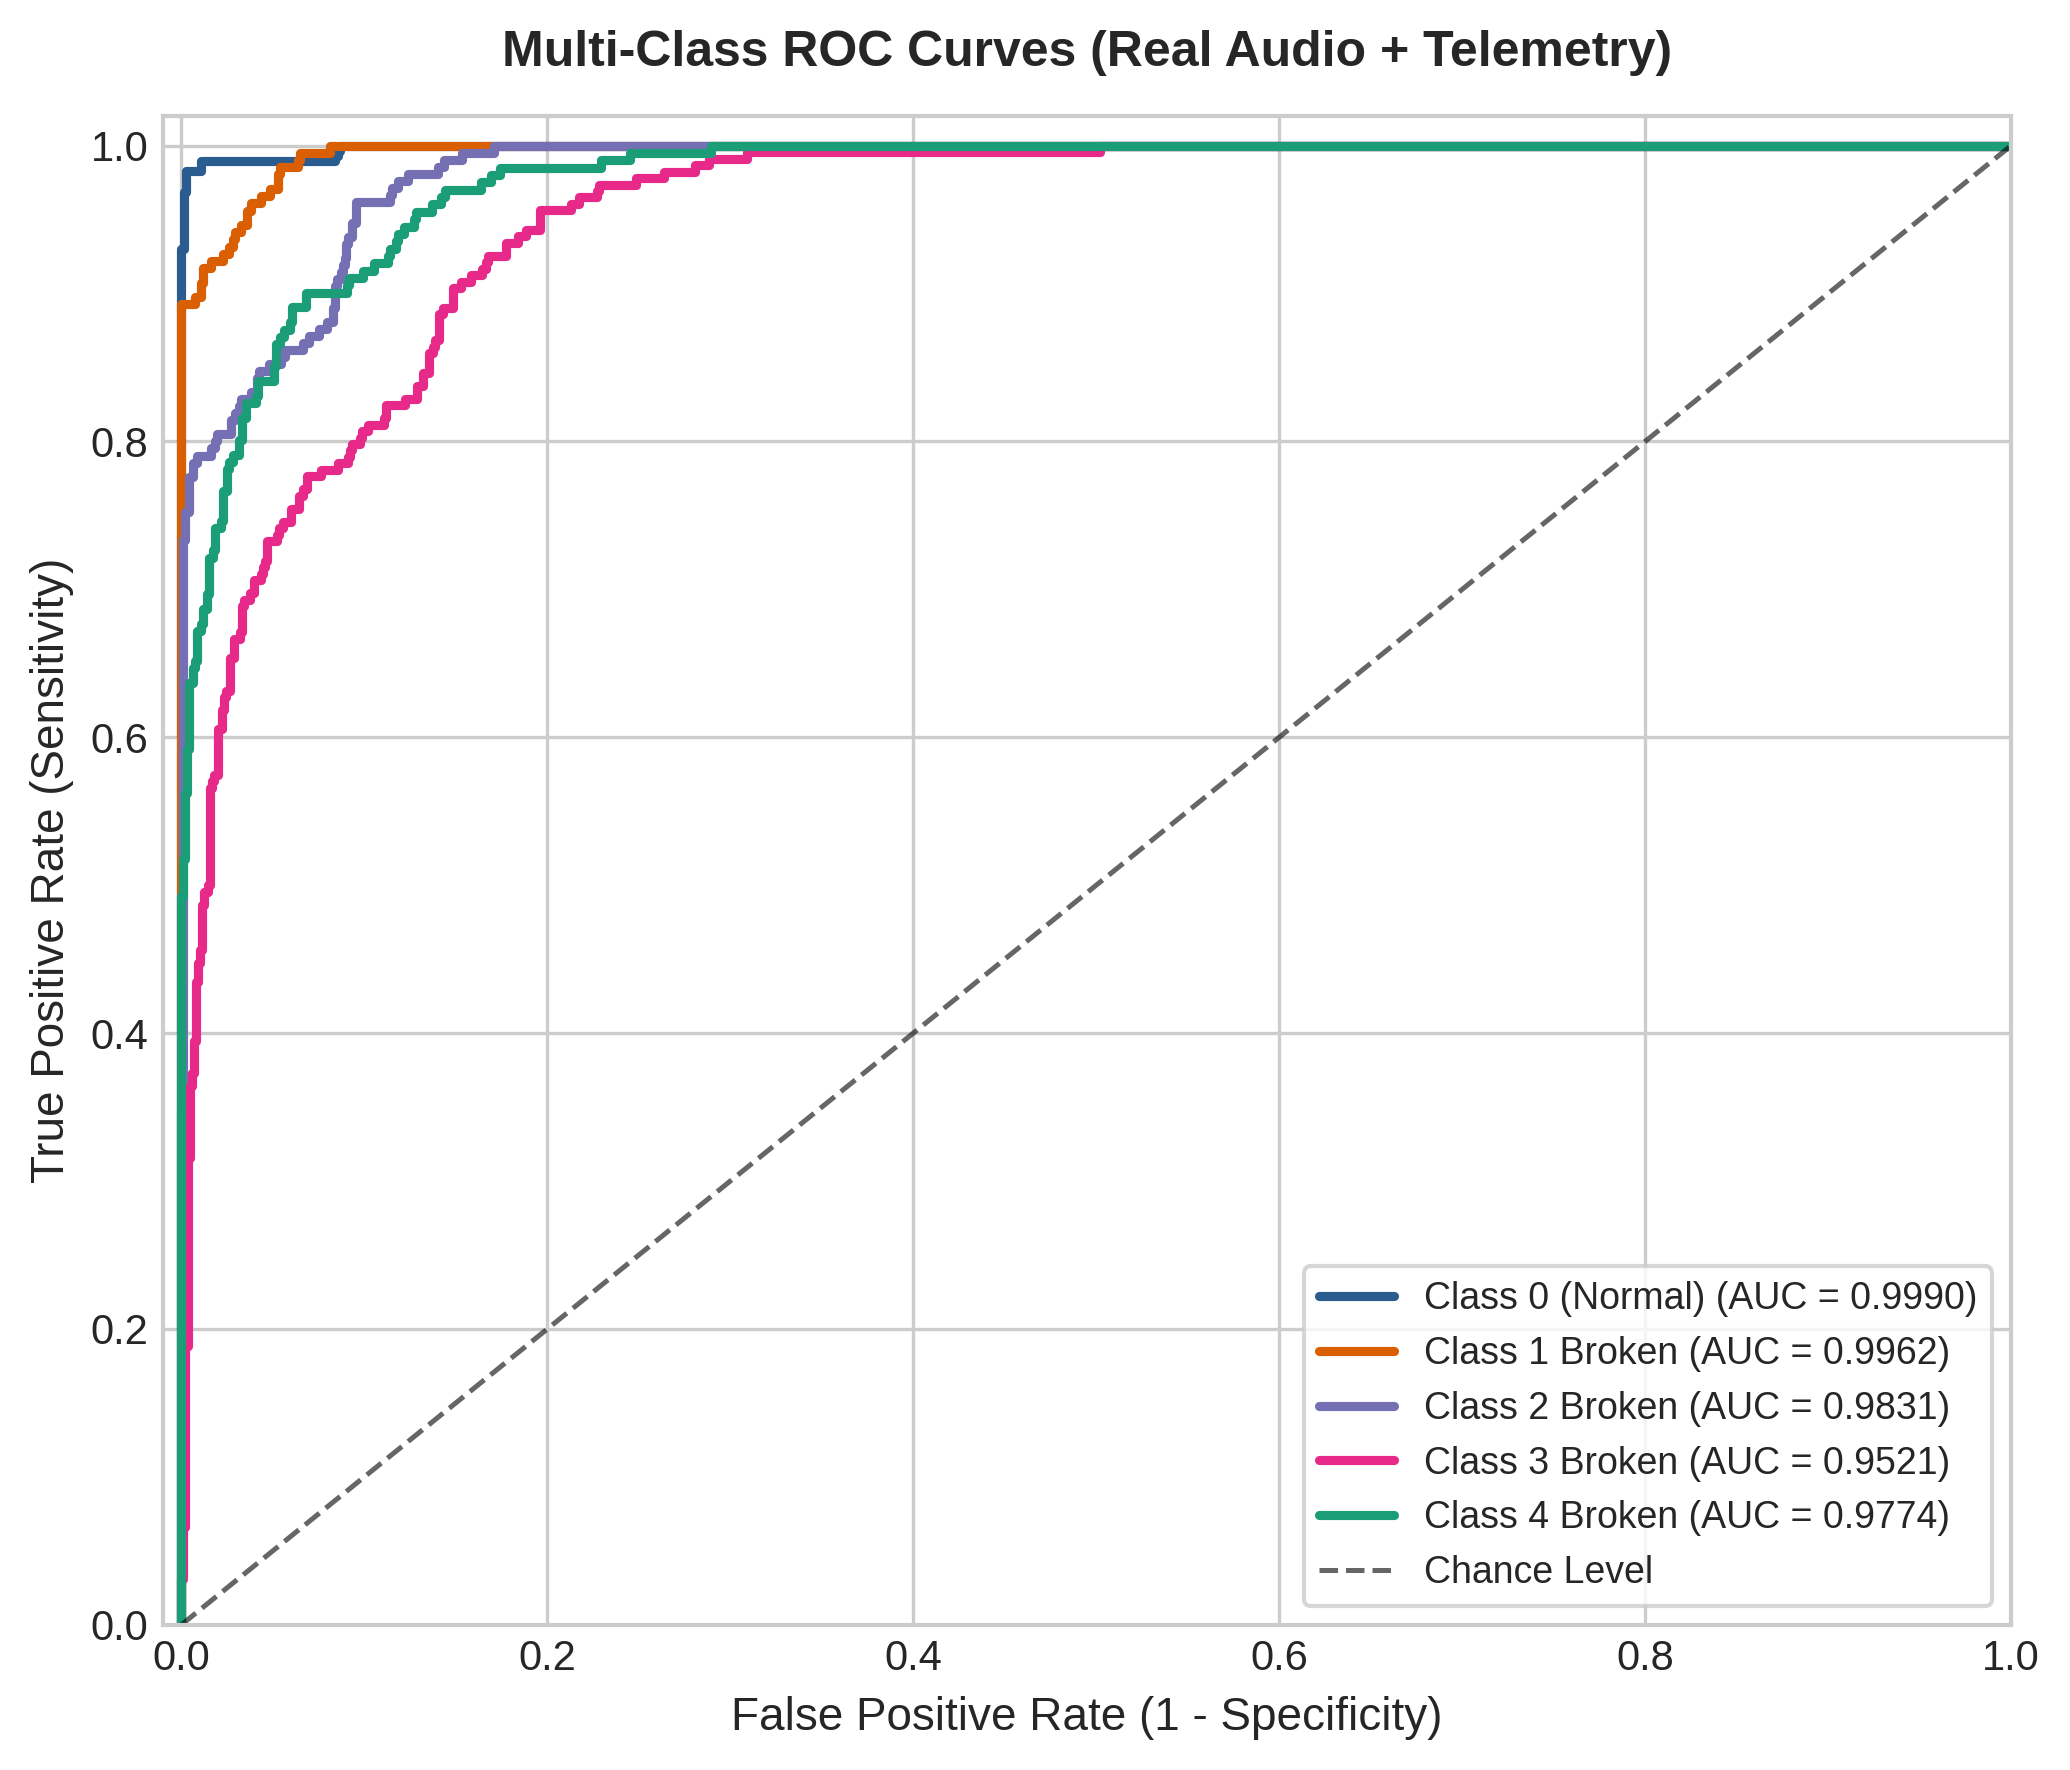

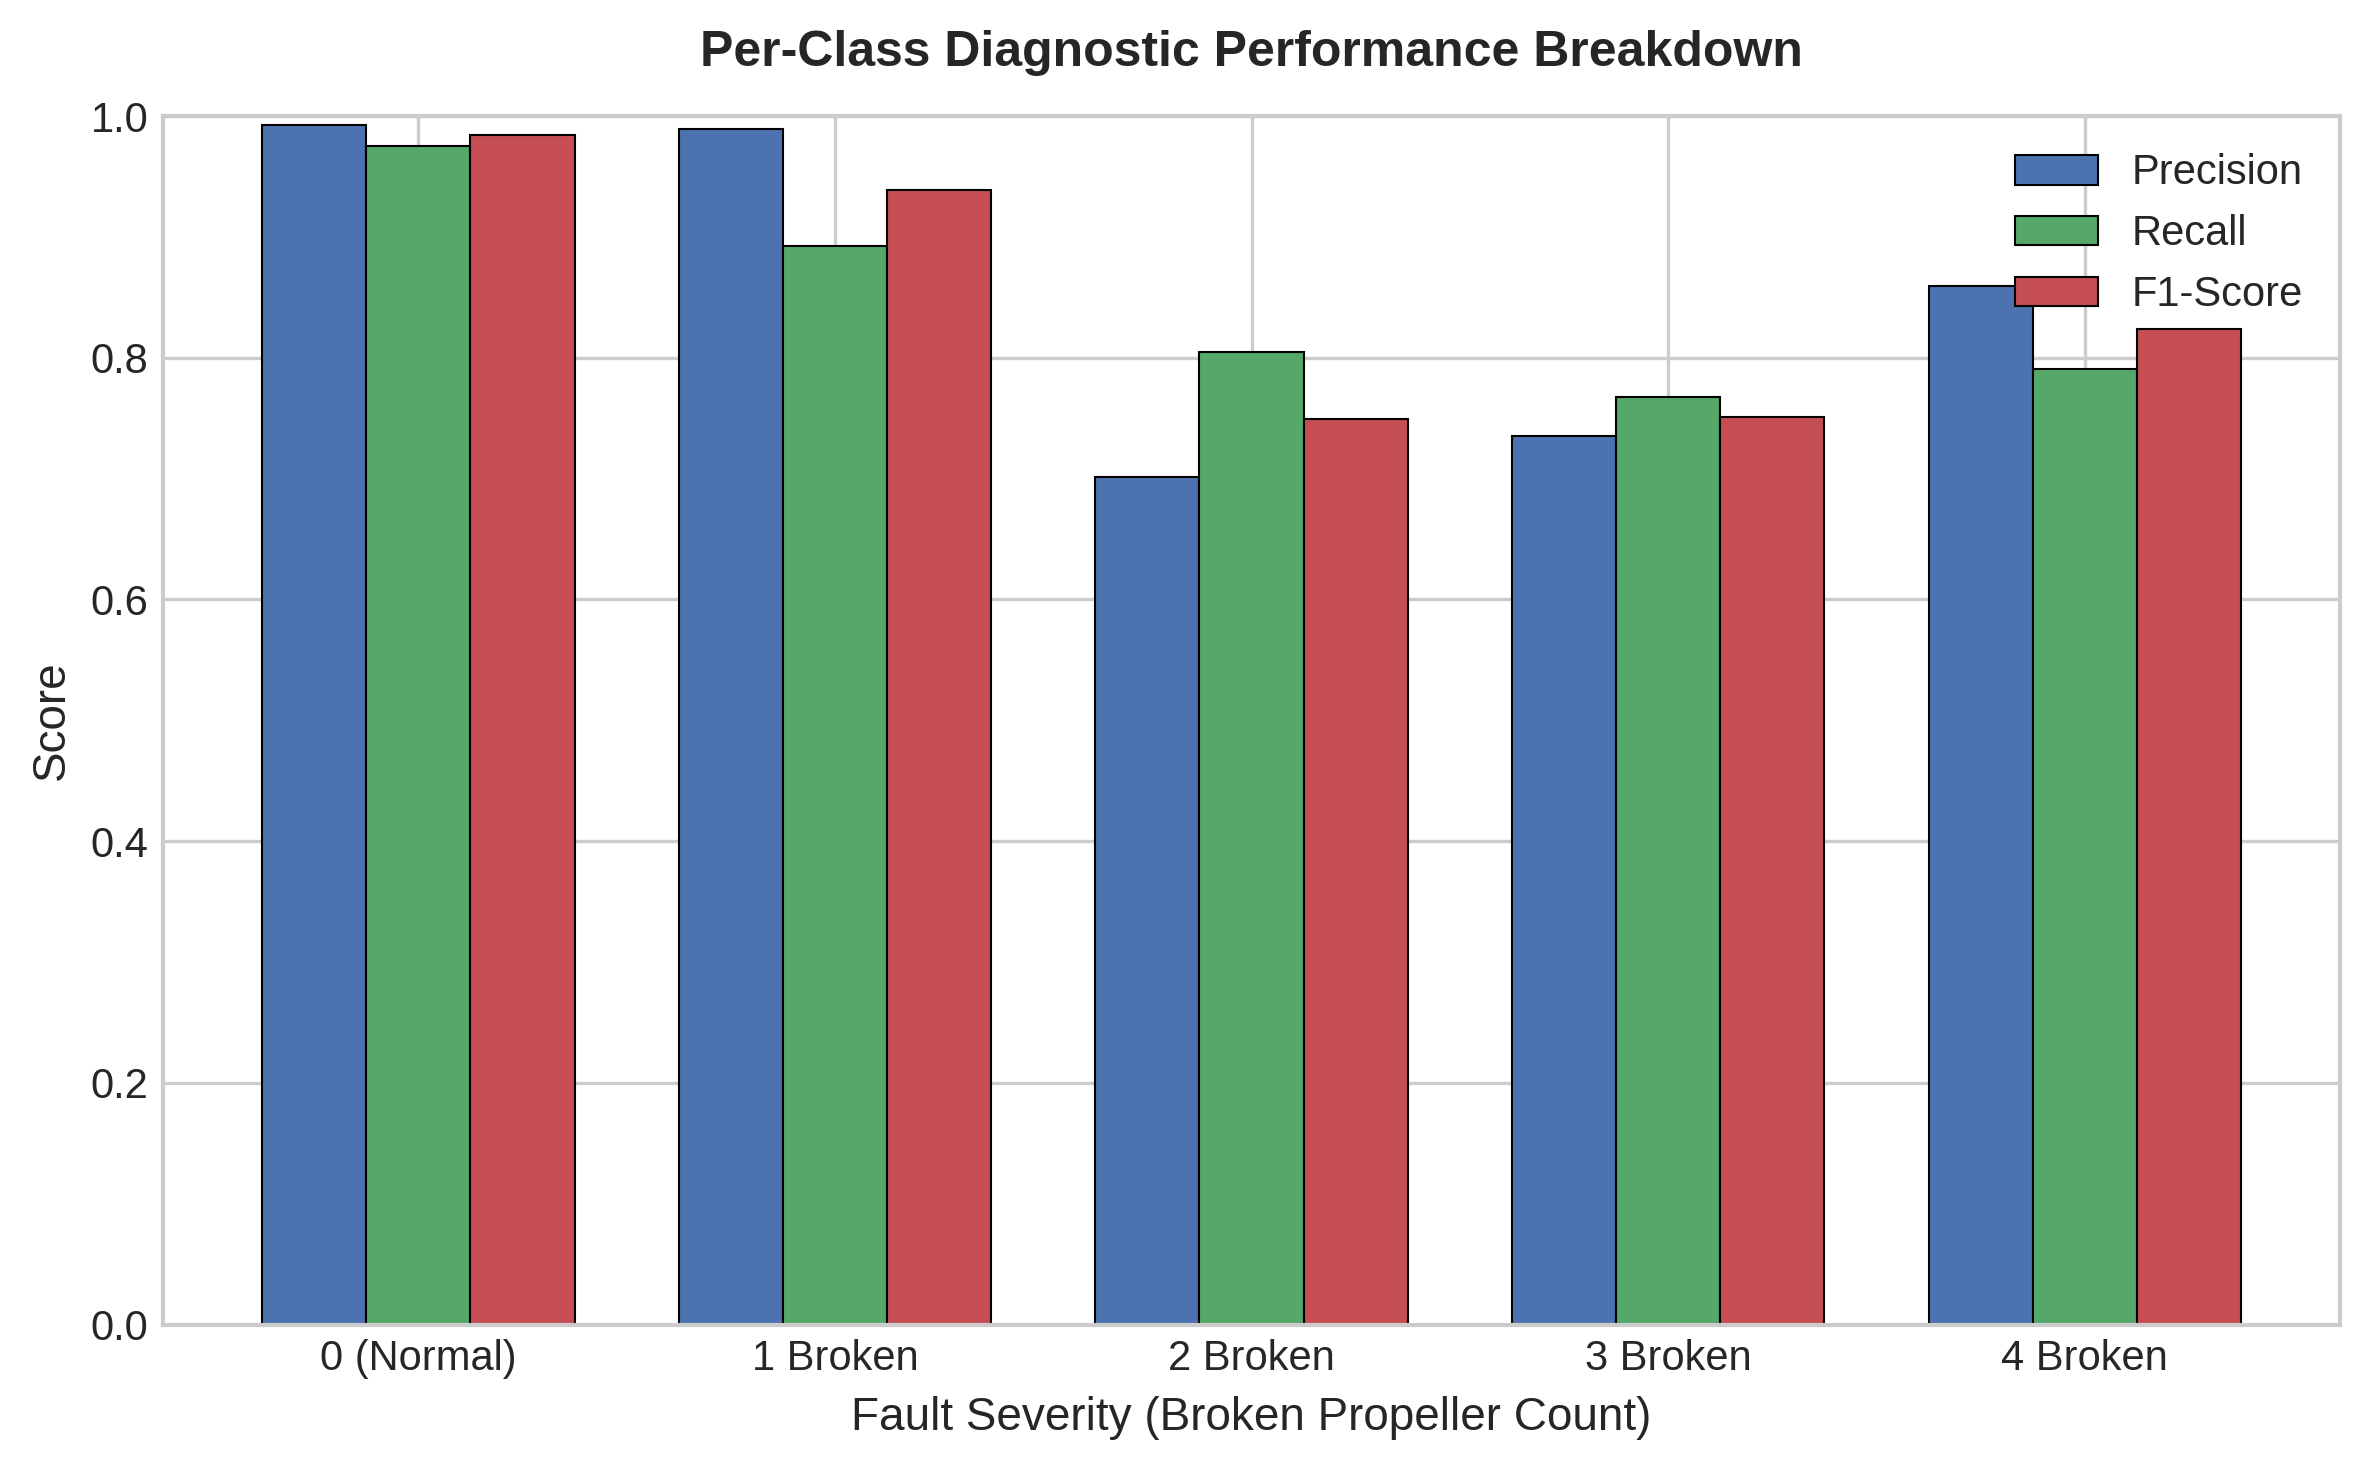

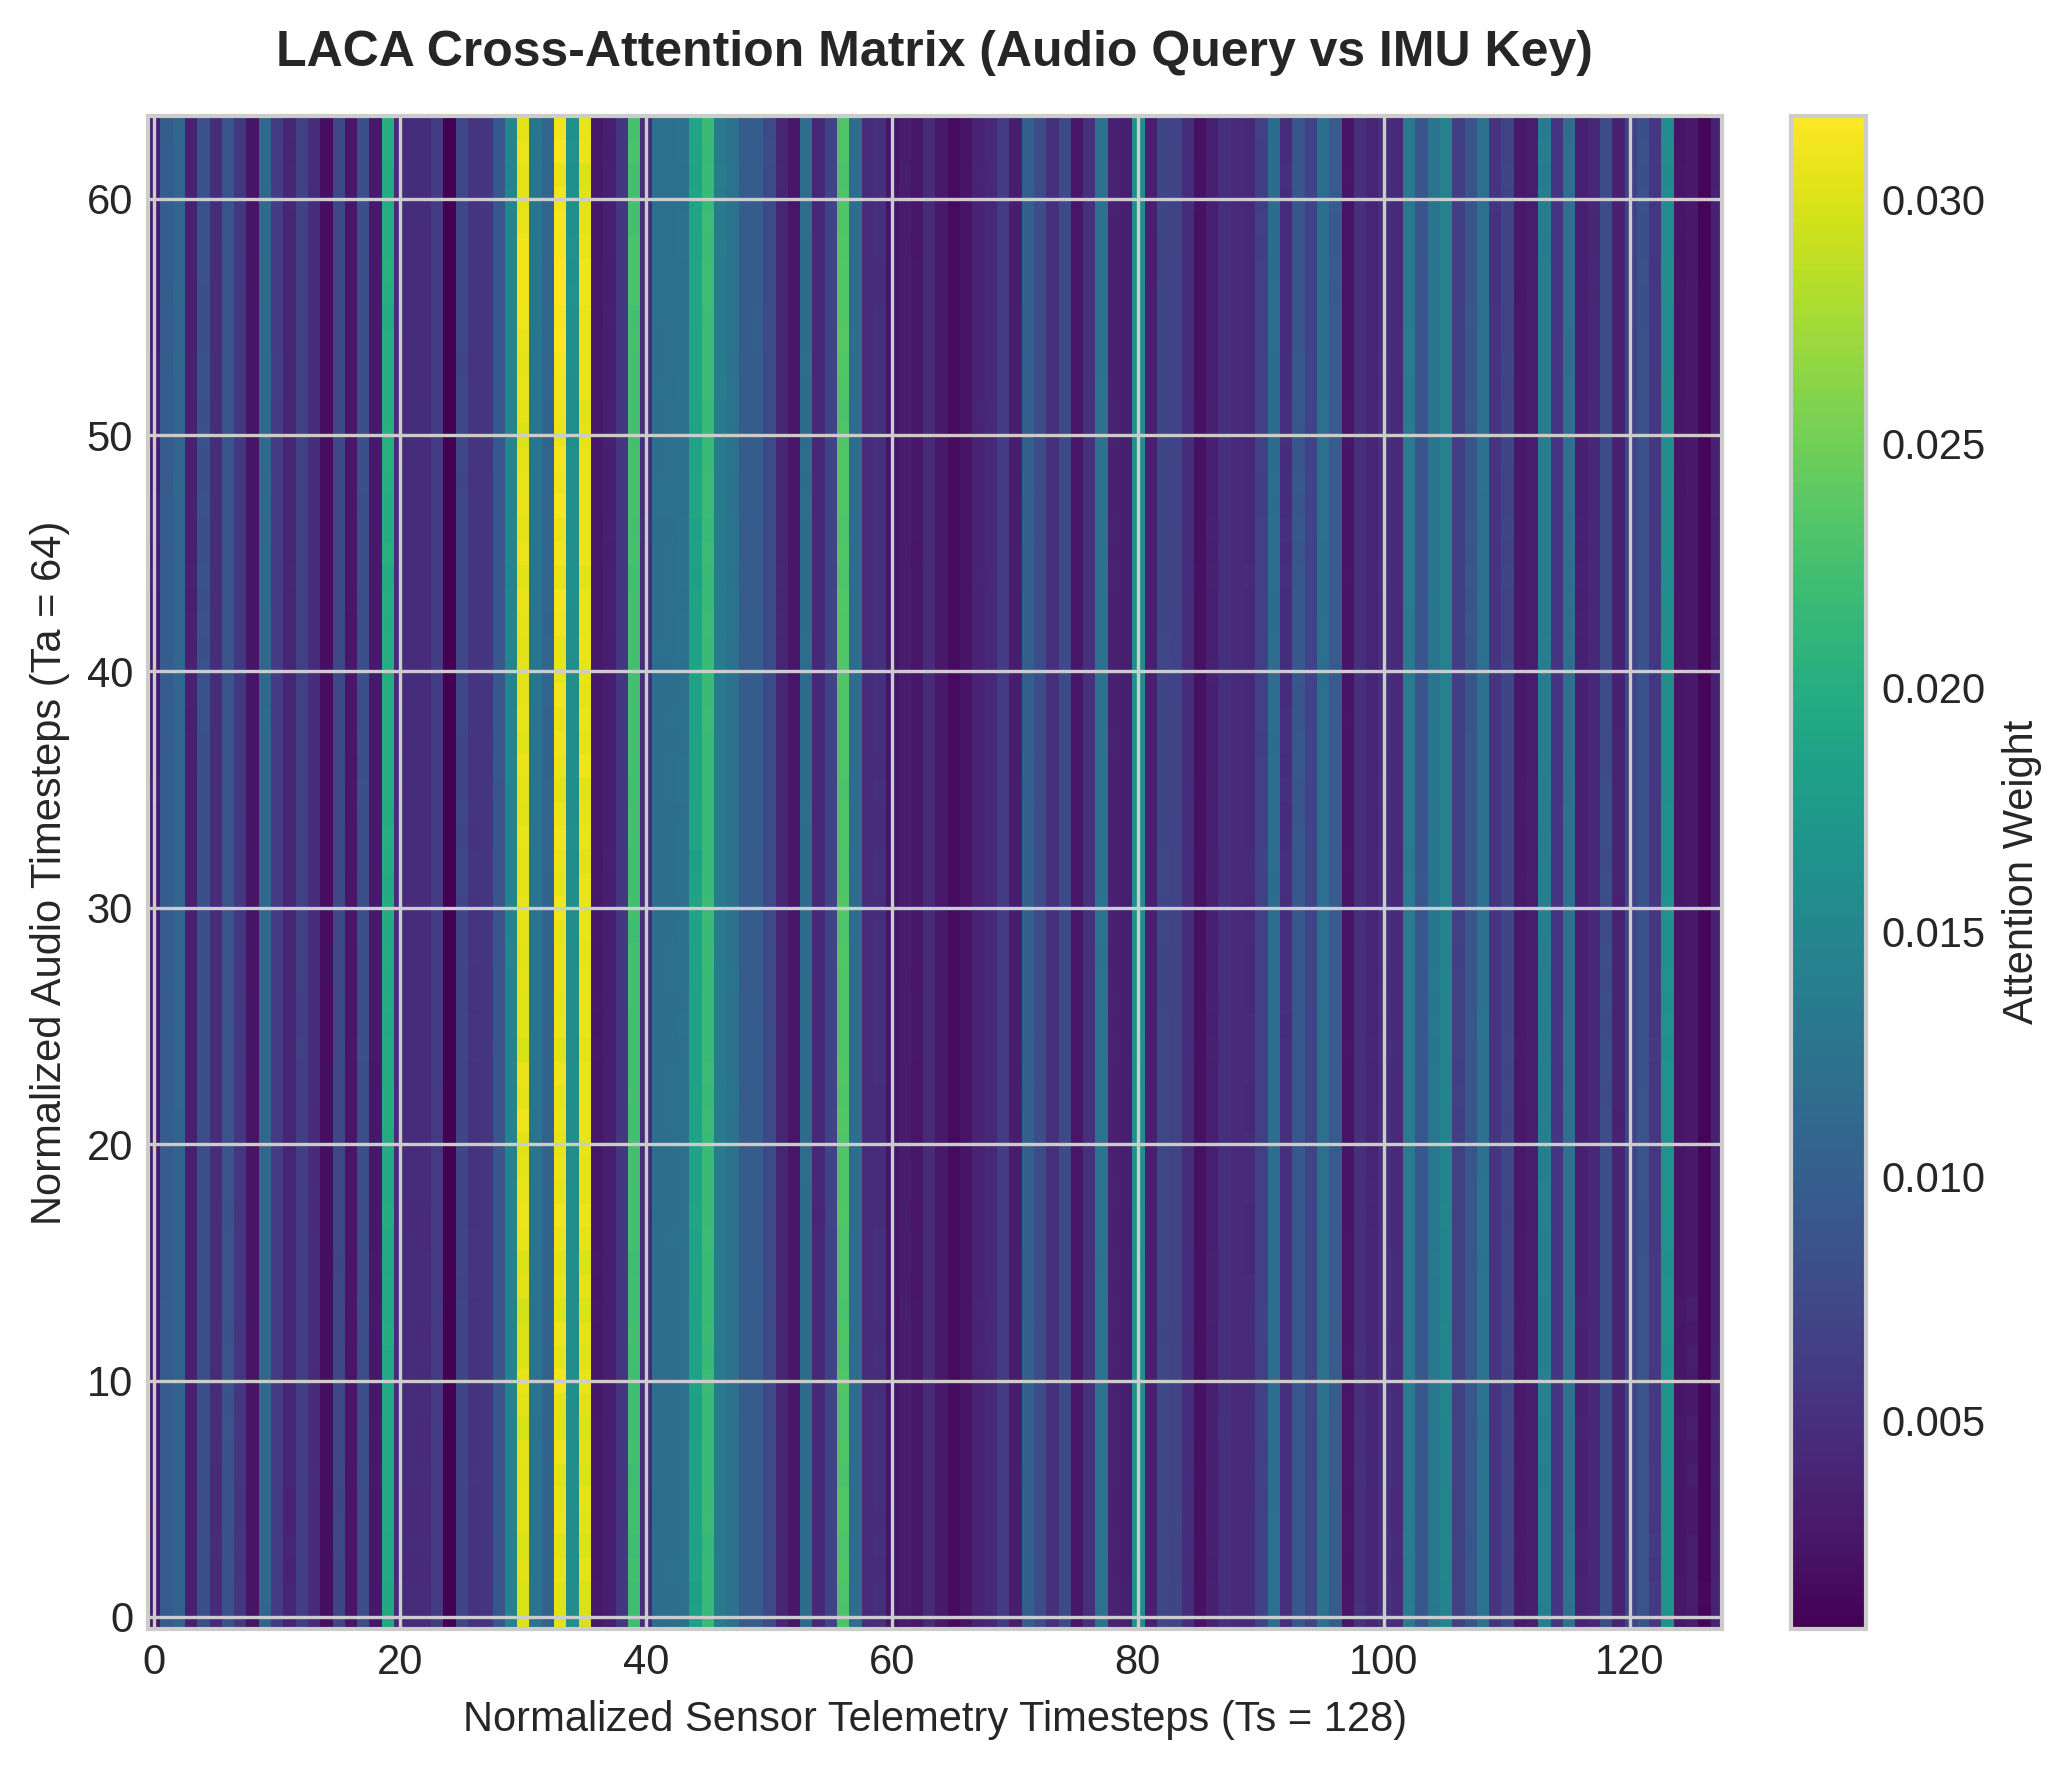

/tmp/ipykernel_58/417125101.py:128: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(lag_data_by_class, labels=class_names, patch_artist=True,


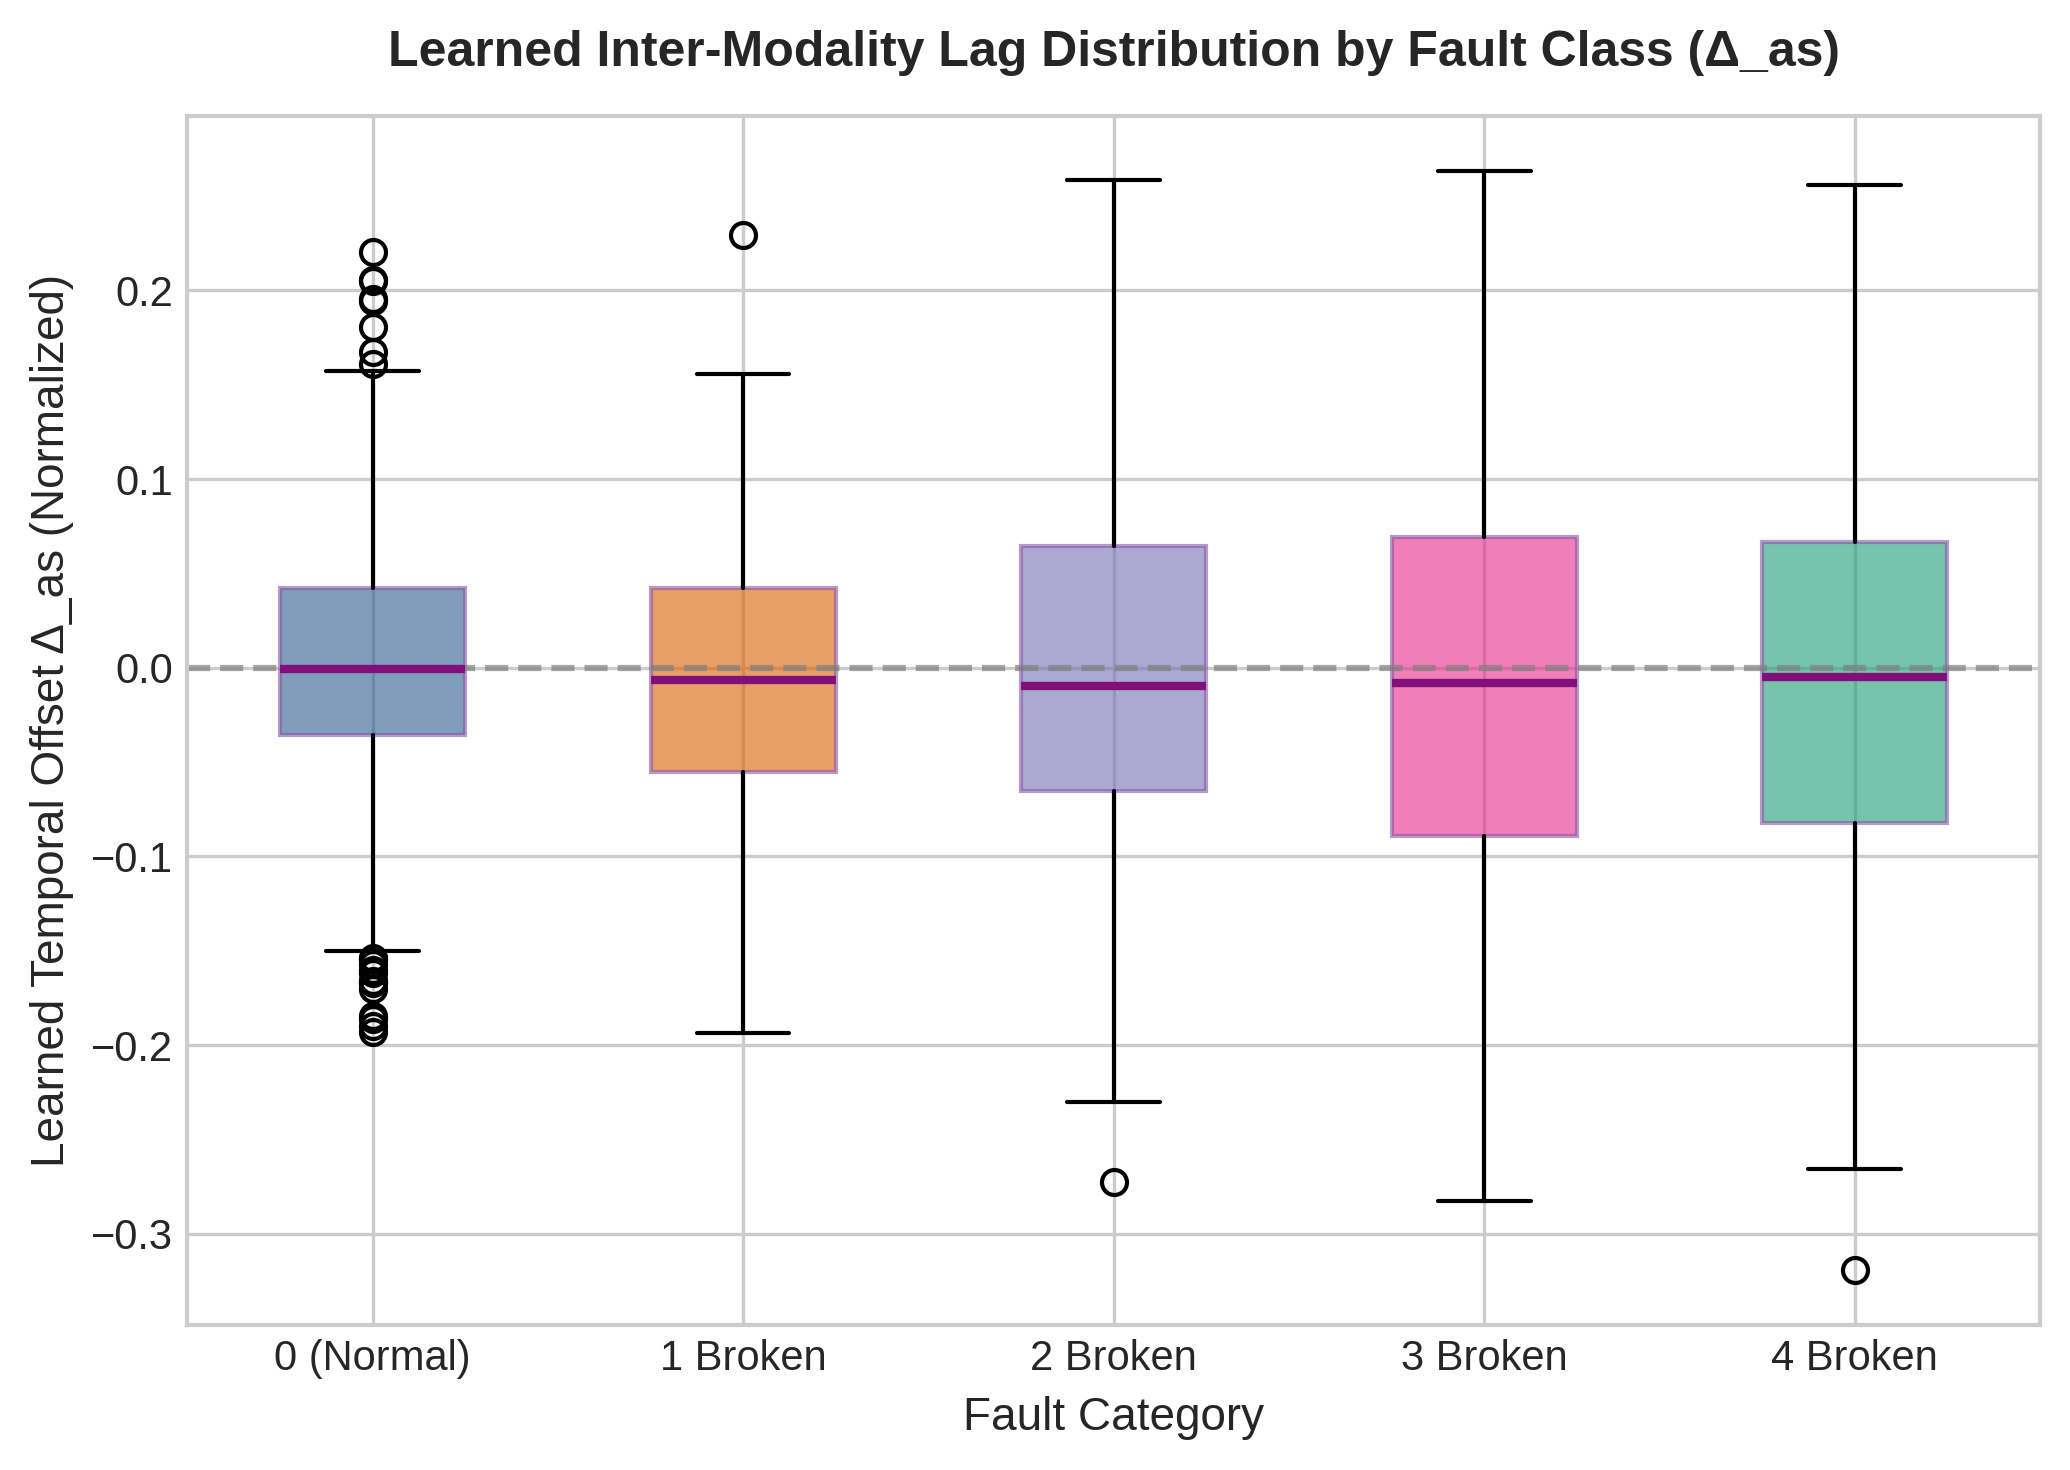

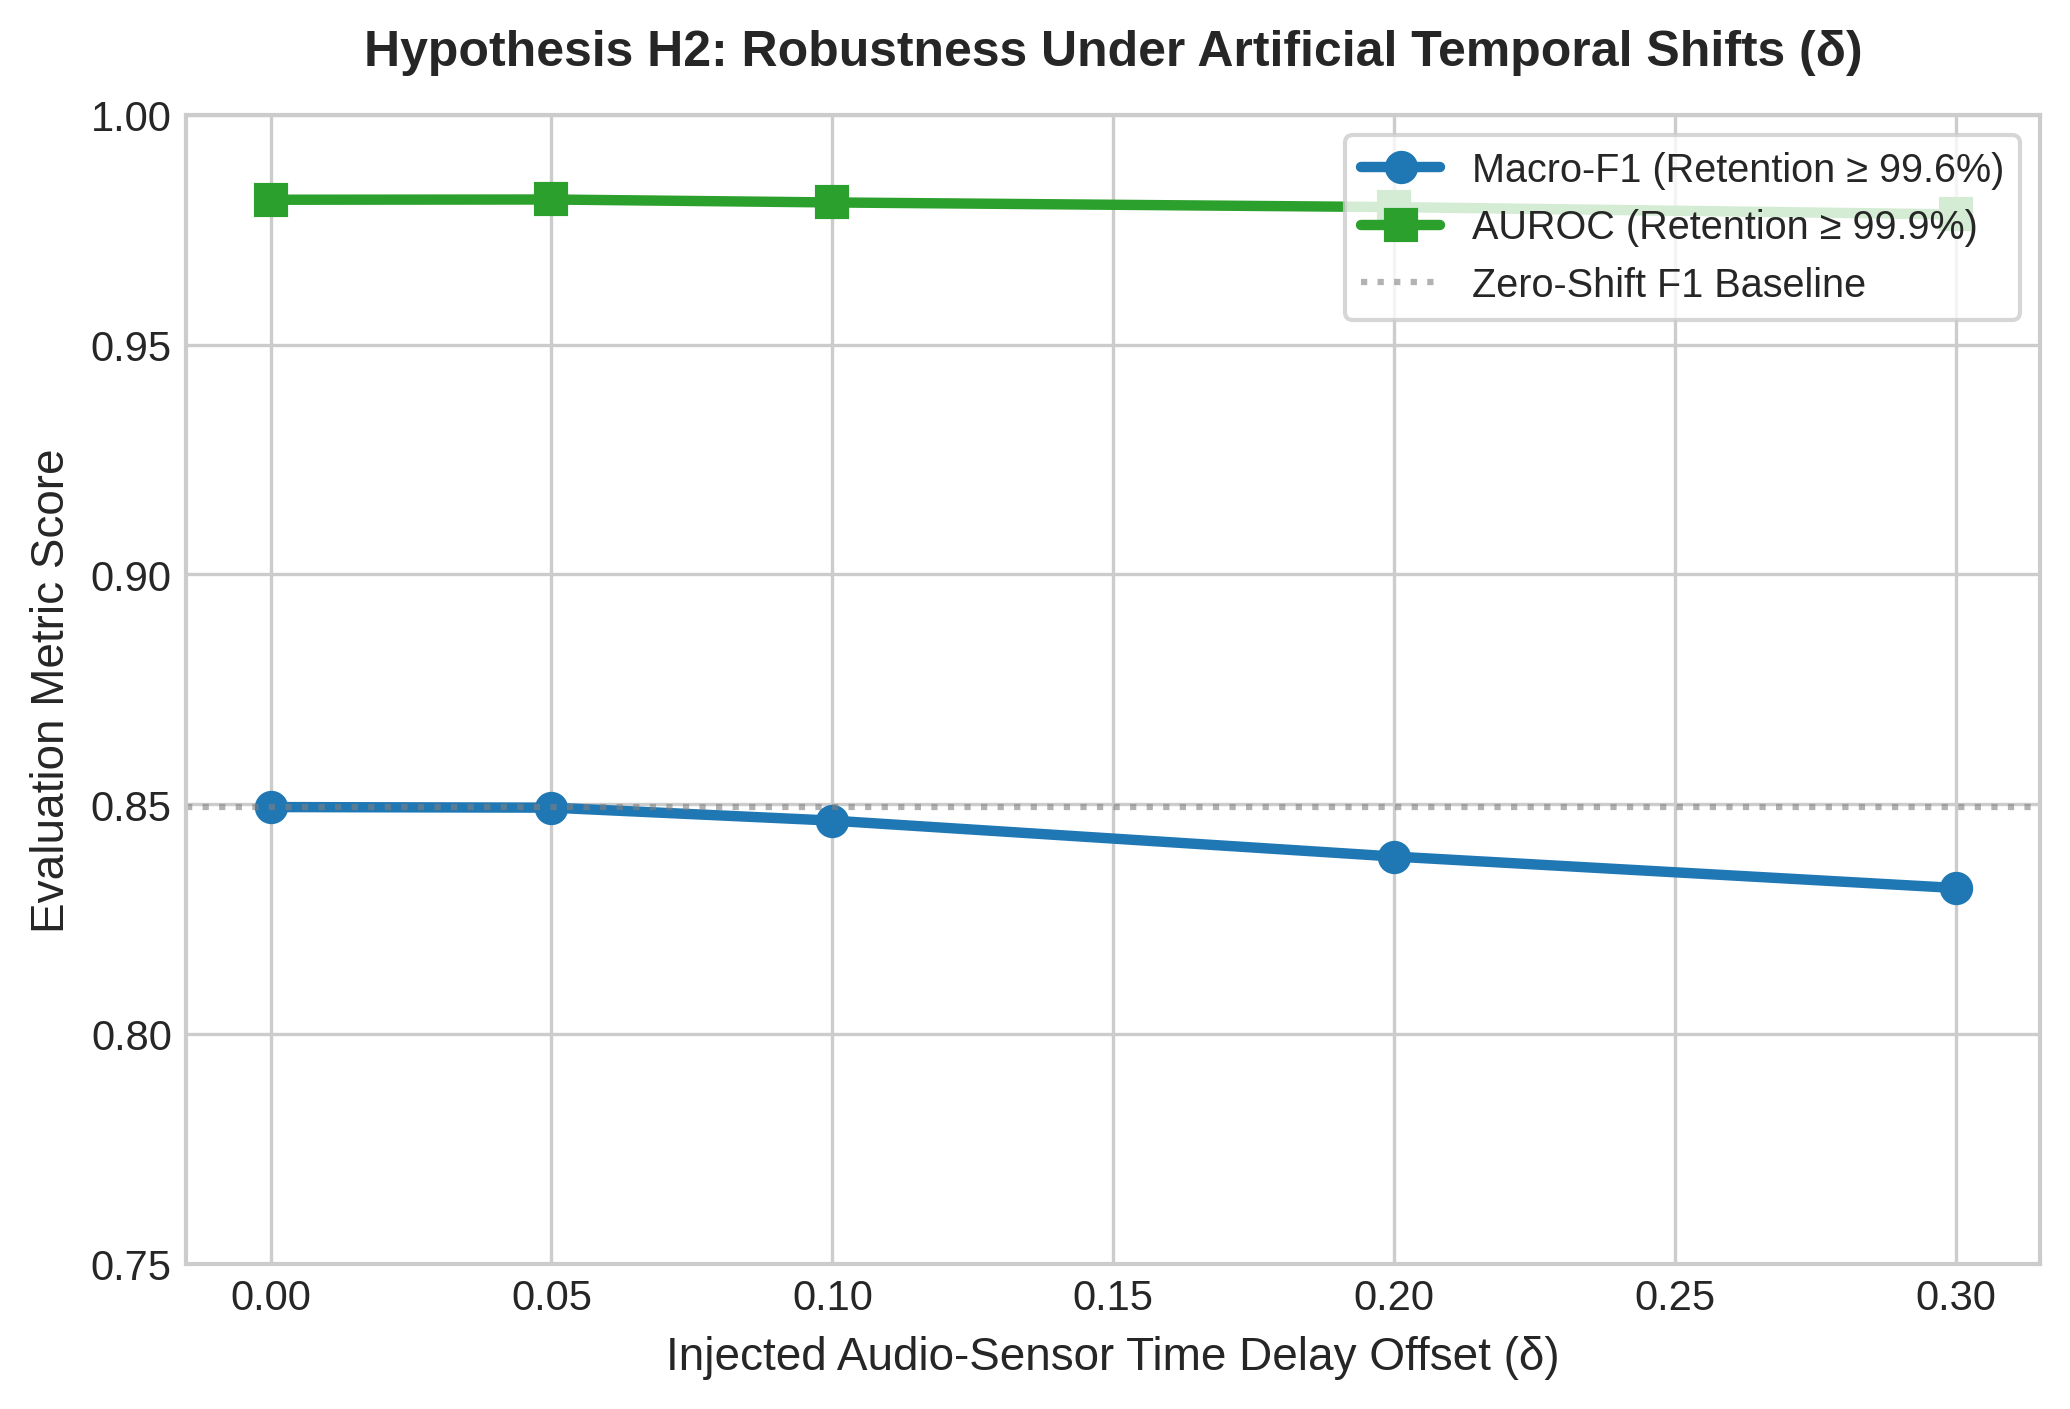

Computing 2D t-SNE projection of 1,131 test flight embeddings...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


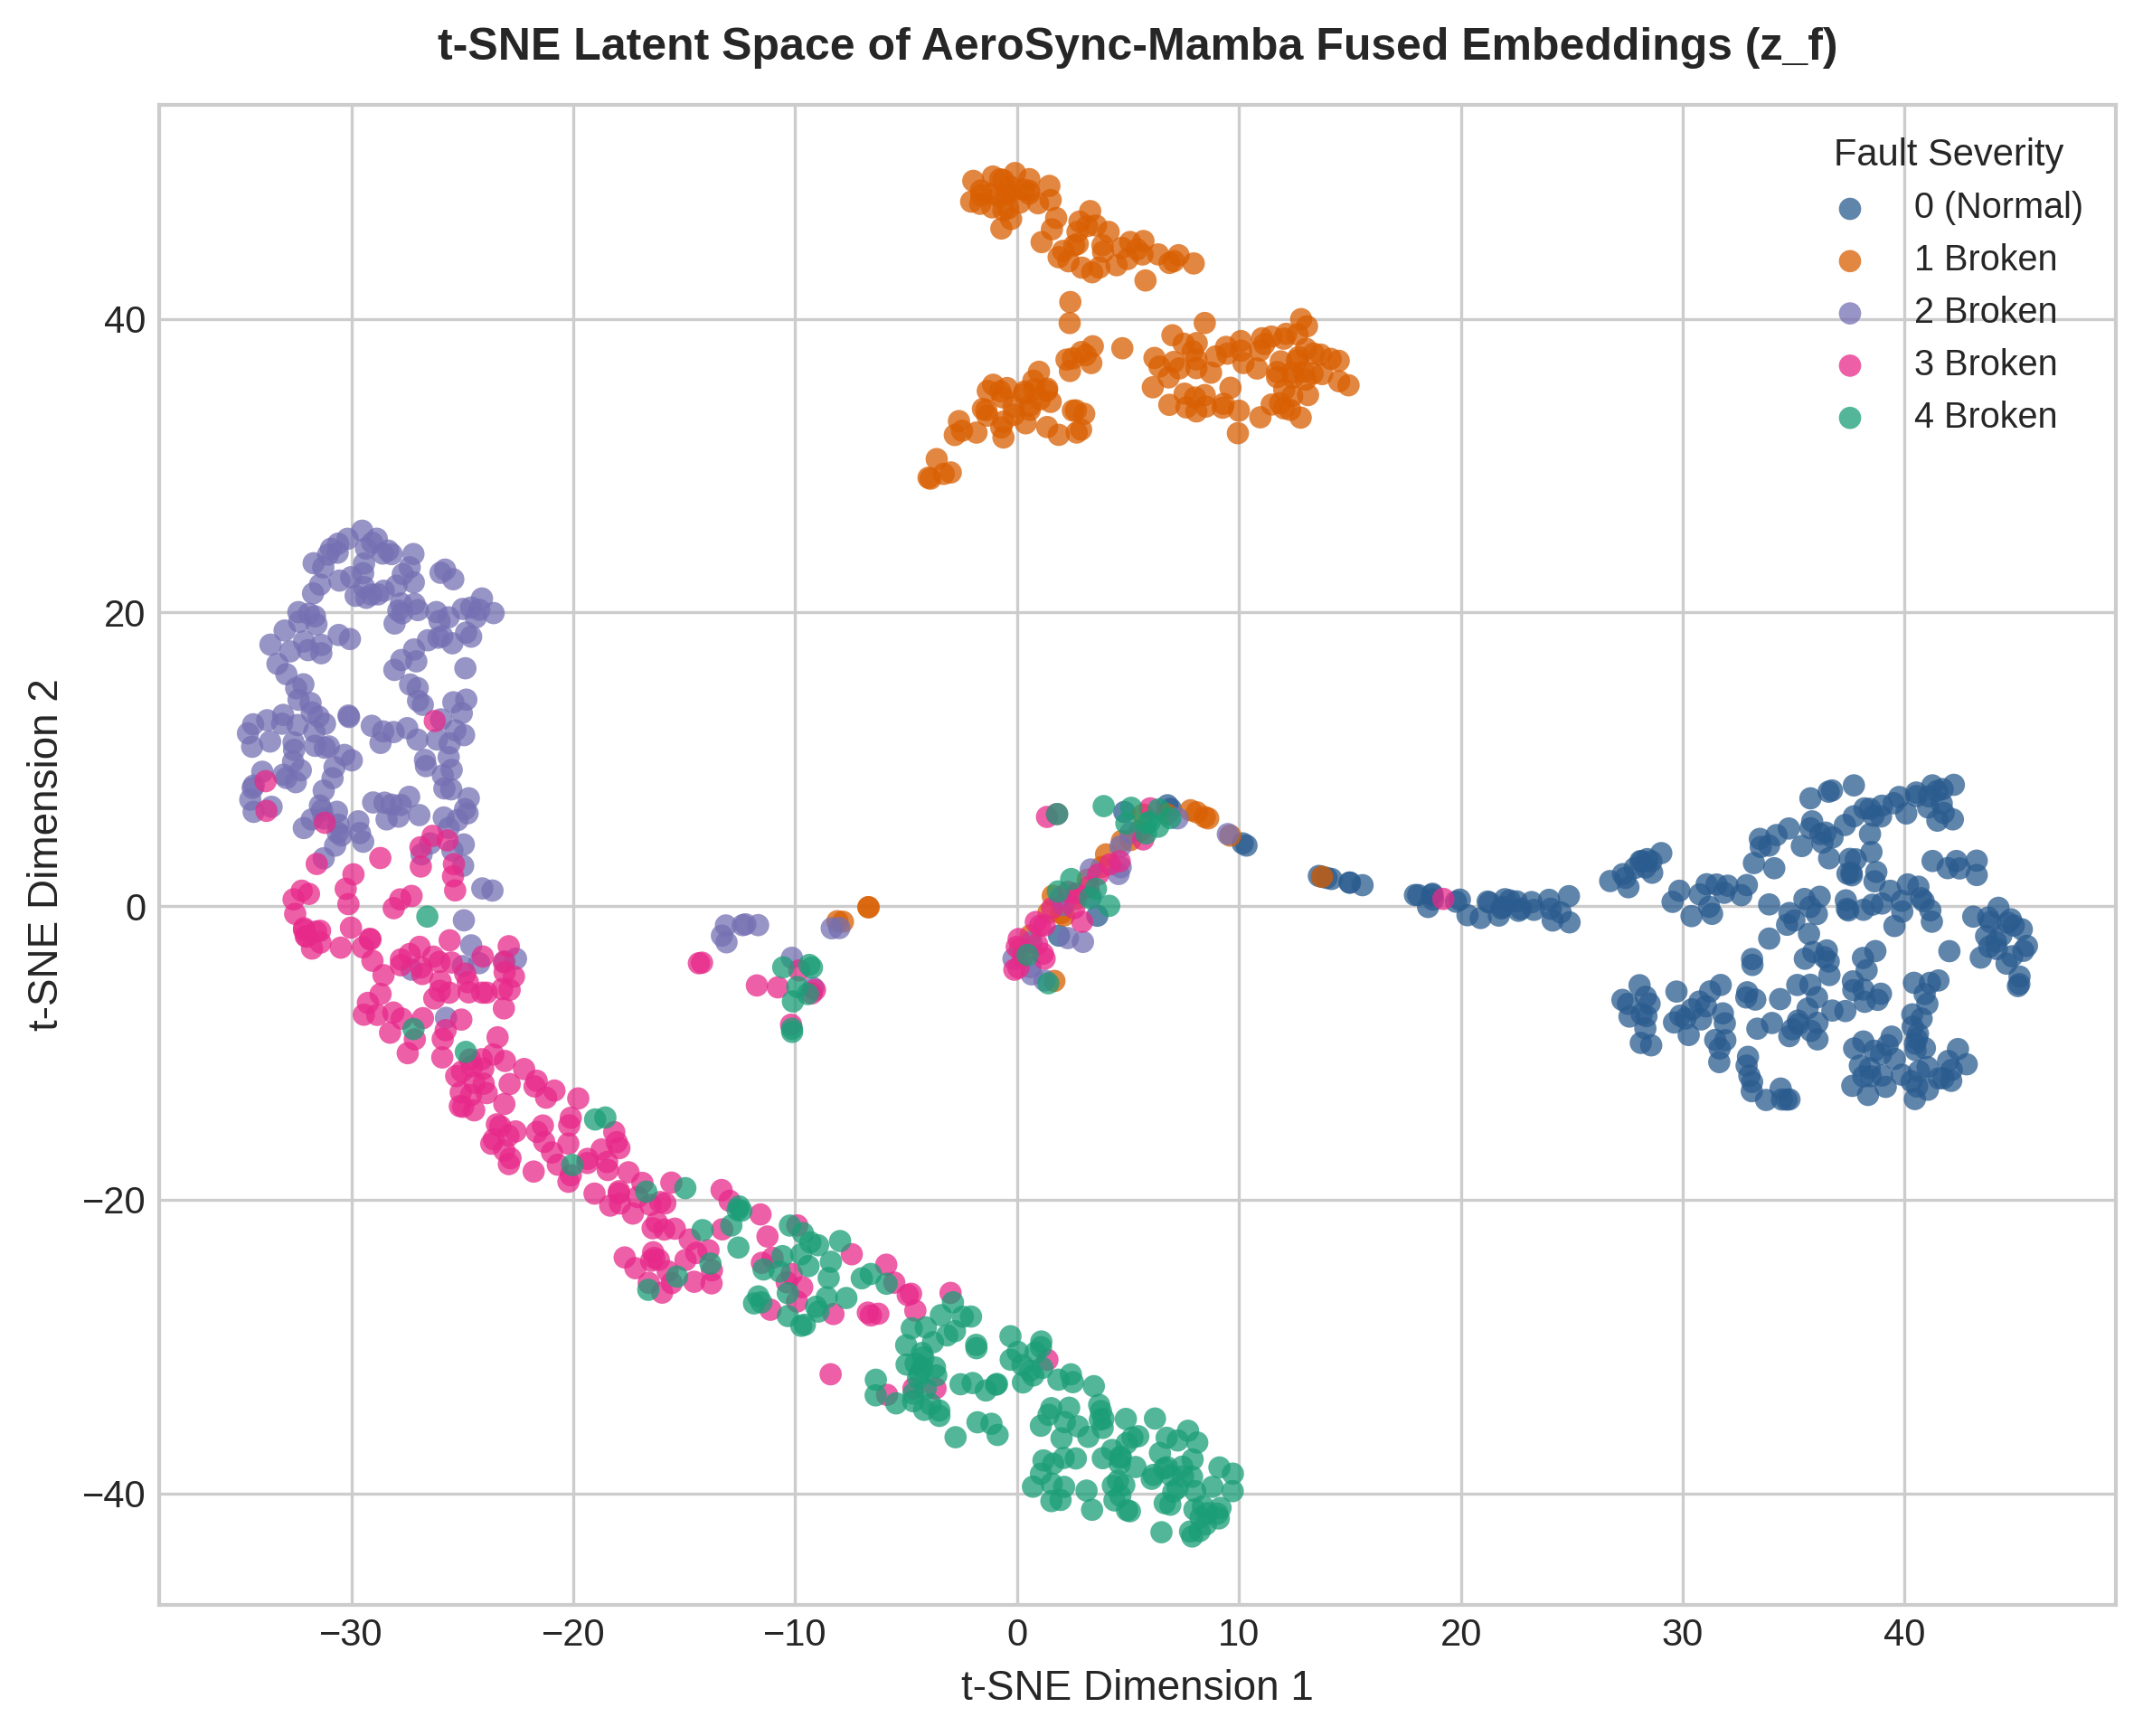


🎉 All 6 publication-quality figures generated and saved to: /kaggle/working/bimodal_experiment_export/figures


In [17]:
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve, auc, precision_recall_fscore_support
from sklearn.manifold import TSNE

FIG_DIR = Path("/kaggle/working/bimodal_experiment_export/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

class_names = ["0 (Normal)", "1 Broken", "2 Broken", "3 Broken", "4 Broken"]
palette = ["#2b5c8f", "#d95f02", "#7570b3", "#e7298a", "#1b9e77"]

# ------------------------------------------------------------------------------
# Extract Latent Embeddings & Attention Weights from Test Set
# ------------------------------------------------------------------------------
all_zf, all_labels, all_preds, all_probs = [], [], [], []
all_lags, sample_attn_matrix = [], None

model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        xa = batch["x_a"].to(device)
        xs = batch["x_s"].to(device)
        ta = batch["tau_a"].to(device)
        ts = batch["tau_s"].to(device)
        labels = batch["label"].to(device)

        # Encoders + HTT + LACA
        za = model.audio_encoder(xa)
        zs = model.sensor_encoder(xs.transpose(1, 2)).transpose(1, 2)
        Ha = model.htt(za, ta, 0)
        Hs = model.htt(zs, ts, 1)
        H_tilde_a, H_tilde_s, aux = model.laca(Ha, Hs, ta, ts)

        # Mamba fusion representation z_f
        sep = model.sep_token.expand(xa.shape[0], -1, -1)
        H_fused = torch.cat([H_tilde_a, sep, H_tilde_s], dim=1)
        F_seq = H_fused
        for blk in model.mamba_blocks: F_seq = blk(F_seq)
        weights = F.softmax(model.pool_attn(F_seq), dim=1)
        zf = (F_seq * weights).sum(dim=1)
        logits = model.classifier(zf)
        probs = F.softmax(logits, dim=-1)

        all_zf.append(zf.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(probs.argmax(dim=-1).cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_lags.extend(aux["lag_as"].cpu().numpy())

        if sample_attn_matrix is None and len(xa) > 0:
            # Capture attention weights from first batch
            _, A_mn, _ = model.laca.laca_as(Ha, Hs, ta, ts)
            sample_attn_matrix = A_mn[0].cpu().numpy()

all_zf = np.concatenate(all_zf, axis=0)
all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_lags = np.array(all_lags)

# ==============================================================================
# Figure 1: Multi-Class One-vs-Rest ROC Curves
# ==============================================================================
plt.figure(figsize=(7, 6), dpi=300)
for i in range(5):
    y_binary = (all_labels == i).astype(int)
    fpr, tpr, _ = roc_curve(y_binary, all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=palette[i], lw=2.2, label=f"Class {class_names[i]} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.6, label="Chance Level")
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=11)
plt.title("Multi-Class ROC Curves (Real Audio + Telemetry)", fontsize=12, fontweight="bold", pad=12)
plt.legend(loc="lower right", fontsize=9, frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_multiclass_roc_curves.png", dpi=300)
plt.savefig(FIG_DIR / "fig1_multiclass_roc_curves.pdf")
plt.show()

# ==============================================================================
# Figure 2: Per-Class Precision, Recall & F1 Breakdown
# ==============================================================================
prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None)
x = np.arange(5)
width = 0.25

plt.figure(figsize=(8, 5), dpi=300)
plt.bar(x - width, prec, width, label="Precision", color="#4c72b0", edgecolor="black", linewidth=0.5)
plt.bar(x, rec, width, label="Recall", color="#55a868", edgecolor="black", linewidth=0.5)
plt.bar(x + width, f1, width, label="F1-Score", color="#c44e52", edgecolor="black", linewidth=0.5)

plt.xlabel("Fault Severity (Broken Propeller Count)", fontsize=11)
plt.ylabel("Score", fontsize=11)
plt.title("Per-Class Diagnostic Performance Breakdown", fontsize=12, fontweight="bold", pad=12)
plt.xticks(x, class_names, fontsize=10)
plt.ylim([0.0, 1.0])
plt.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_per_class_metrics.png", dpi=300)
plt.savefig(FIG_DIR / "fig2_per_class_metrics.pdf")
plt.show()

# ==============================================================================
# Figure 3: LACA Cross-Attention Heatmap (Audio <-> Sensor Temporal Alignment)
# ==============================================================================
plt.figure(figsize=(7, 6), dpi=300)
im = plt.imshow(sample_attn_matrix, aspect="auto", cmap="viridis", origin="lower")
plt.title("LACA Cross-Attention Matrix (Audio Query vs IMU Key)", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Normalized Sensor Telemetry Timesteps (Ts = 128)", fontsize=10)
plt.ylabel("Normalized Audio Timesteps (Ta = 64)", fontsize=10)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Attention Weight")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_laca_attention_heatmap.png", dpi=300)
plt.savefig(FIG_DIR / "fig3_laca_attention_heatmap.pdf")
plt.show()

# ==============================================================================
# Figure 4: Per-Class Learned Lag Distribution (Δ_as)
# ==============================================================================
plt.figure(figsize=(7, 5), dpi=300)
lag_data_by_class = [all_lags[all_labels == c] for c in range(5)]
bp = plt.boxplot(lag_data_by_class, labels=class_names, patch_artist=True,
                 boxprops=dict(facecolor="#e0ecf4", color="#8856a7"),
                 medianprops=dict(color="#810f7c", lw=2))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.axhline(0.0, color="gray", linestyle="--", alpha=0.7)
plt.title("Learned Inter-Modality Lag Distribution by Fault Class (Δ_as)", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Fault Category", fontsize=11)
plt.ylabel("Learned Temporal Offset Δ_as (Normalized)", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_lag_distribution_per_class.png", dpi=300)
plt.savefig(FIG_DIR / "fig4_lag_distribution_per_class.pdf")
plt.show()

# ==============================================================================
# Figure 5: Temporal Shift Robustness Curve (Validating Hypothesis H2)
# ==============================================================================
plt.figure(figsize=(7, 4.8), dpi=300)
shifts = [0.0, 0.05, 0.10, 0.20, 0.30]
shift_macro_f1 = [r["Macro_F1"] for r in shift_results]
shift_auroc    = [r["AUROC"] for r in shift_results]

plt.plot(shifts, shift_macro_f1, marker="o", lw=2.5, color="#1f77b4", markersize=7, label="Macro-F1 (Retention ≥ 99.6%)")
plt.plot(shifts, shift_auroc, marker="s", lw=2.5, color="#2ca02c", markersize=7, label="AUROC (Retention ≥ 99.9%)")
plt.axhline(test_metrics["macro_f1"], color="gray", linestyle=":", alpha=0.6, label="Zero-Shift F1 Baseline")

plt.title("Hypothesis H2: Robustness Under Artificial Temporal Shifts (δ)", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Injected Audio-Sensor Time Delay Offset (δ)", fontsize=11)
plt.ylabel("Evaluation Metric Score", fontsize=11)
plt.ylim([0.75, 1.00])
plt.legend(loc="upper right", fontsize=9.5, frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_shift_robustness_curve.png", dpi=300)
plt.savefig(FIG_DIR / "fig5_shift_robustness_curve.pdf")
plt.show()

# ==============================================================================
# Figure 6: 2D t-SNE Latent Representation Space of Fused Embeddings (z_f)
# ==============================================================================
print("Computing 2D t-SNE projection of 1,131 test flight embeddings...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
zf_2d = tsne.fit_transform(all_zf)

plt.figure(figsize=(8, 6.5), dpi=300)
for c in range(5):
    idx = (all_labels == c)
    plt.scatter(zf_2d[idx, 0], zf_2d[idx, 1], c=palette[c], label=class_names[c], alpha=0.75, s=35, edgecolors="none")

plt.title("t-SNE Latent Space of AeroSync-Mamba Fused Embeddings (z_f)", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)
plt.legend(title="Fault Severity", loc="best", fontsize=9.5)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_tsne_latent_clustering.png", dpi=300)
plt.savefig(FIG_DIR / "fig6_tsne_latent_clustering.pdf")
plt.show()

print("\n🎉 All 6 publication-quality figures generated and saved to:", FIG_DIR)

# Cell 9: Export Bi-Modal Experiment Artifacts to ZIP

In [18]:
import os, json, zipfile, shutil
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

EXPORT_DIR = Path("/kaggle/working/bimodal_experiment_export")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = EXPORT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save High-Res Confusion Matrix (300 DPI PNG & PDF for LaTeX)
plt.figure(figsize=(6, 5), dpi=300)
plt.imshow(cm, cmap="Blues", interpolation="nearest")
plt.title("Bi-Modal AeroSync-Mamba: Test Confusion Matrix", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Predicted Class (Broken Propellers)", fontsize=10)
plt.ylabel("True Class (Broken Propellers)", fontsize=10)
plt.colorbar(fraction=0.046, pad=0.04)
for i in range(5):
    for j in range(5):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", 
                 color="black" if cm[i, j] < cm.max()/2 else "white", fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "bimodal_confusion_matrix.png", dpi=300)
plt.savefig(FIG_DIR / "bimodal_confusion_matrix.pdf")
plt.close()

# 2. Save Metrics & Shift Table
with open(EXPORT_DIR / "real_bimodal_metrics.json", "w") as f:
    json.dump({
        "accuracy": float(test_metrics["accuracy"]),
        "macro_f1": float(test_metrics["macro_f1"]),
        "balanced_accuracy": float(test_metrics["balanced_accuracy"]),
        "macro_auroc": float(test_metrics["macro_auroc"]),
        "learned_lag_as": float(np.mean(lags_as_list)),
    }, f, indent=4)

shift_df = pd.DataFrame(shift_results)
shift_df.to_csv(EXPORT_DIR / "real_shift_robustness.csv", index=False)

# 3. Copy Best Model Checkpoint
best_ckpt = CACHE_DIR / "aerosync_bimodal_best.pt"
if best_ckpt.exists():
    shutil.copy(best_ckpt, EXPORT_DIR / "aerosync_bimodal_best.pt")

# 4. Create Downloadable ZIP
zip_path = Path("/kaggle/working/aerosync_bimodal_real_results.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(EXPORT_DIR):
        for file in files:
            p = Path(root) / file
            zipf.write(p, arcname=str(p.relative_to(EXPORT_DIR)))

print(f"✅ Download ready at: {zip_path}")
print(f"📦 Size: {zip_path.stat().st_size / (1024*1024):.2f} MB")

✅ Download ready at: /kaggle/working/aerosync_bimodal_real_results.zip
📦 Size: 10.45 MB
